# Project Roadmap: Cryptocurrency Liquidity Prediction


## Phase 1: Data Collection & Setup
Objective: Load and inspect the dataset from the provided Google Drive link.
Tasks:
- Download the dataset from this folder
- Load it using pandas and inspect basic structure (head(), info(), describe())
- Identify key columns: price, volume, timestamp, etc.


In [90]:
#Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [91]:
df1 = pd.read_csv('..\datasets\coin_gecko_2022-03-16.csv')
df2 = pd.read_csv('..\datasets\coin_gecko_2022-03-17.csv')

df1.head()
df2.head()
df = pd.concat([df1, df2])
print(df.head())

       coin symbol         price     1h    24h     7d    24h_volume  \
0   Bitcoin    BTC  40859.460000  0.022  0.030  0.055  3.539076e+10   
1  Ethereum    ETH   2744.410000  0.024  0.034  0.065  1.974870e+10   
2    Tether   USDT      1.000000 -0.001 -0.001  0.000  5.793497e+10   
3       BNB    BNB    383.430000  0.018  0.028  0.004  1.395854e+09   
4  USD Coin   USDC      0.999874 -0.001  0.000 -0.000  3.872274e+09   

        mkt_cap        date  
0  7.709915e+11  2022-03-16  
1  3.271044e+11  2022-03-16  
2  7.996516e+10  2022-03-16  
3  6.404382e+10  2022-03-16  
4  5.222214e+10  2022-03-16  


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   coin        1000 non-null   object 
 1   symbol      1000 non-null   object 
 2   price       1000 non-null   float64
 3   1h          993 non-null    float64
 4   24h         993 non-null    float64
 5   7d          992 non-null    float64
 6   24h_volume  993 non-null    float64
 7   mkt_cap     1000 non-null   float64
 8   date        1000 non-null   object 
dtypes: float64(6), object(3)
memory usage: 78.1+ KB


In [24]:
print(df.describe())

              price          1h         24h          7d    24h_volume  \
count  1.000000e+03  993.000000  993.000000  992.000000  9.930000e+02   
mean   6.561060e+02    0.009723    0.023737    0.023558  2.893109e+08   
std    4.584655e+03    0.026934    0.059303    0.229781  2.769908e+09   
min    1.484000e-09   -0.704000   -0.646000   -0.558000  0.000000e+00   
25%    1.940547e-01    0.001000    0.001000   -0.041000  1.766976e+06   
50%    1.095000e+00    0.006000    0.016000   -0.000500  8.343005e+06   
75%    7.232500e+00    0.019000    0.035000    0.037000  4.003652e+07   
max    4.121727e+04    0.095000    0.577000    4.608000  5.793497e+10   

            mkt_cap  
count  1.000000e+03  
mean   3.755304e+09  
std    3.803783e+10  
min    6.577043e+07  
25%    1.157776e+08  
50%    2.120036e+08  
75%    5.948436e+08  
max    7.760774e+11  


### Phase 2: Data Preprocessing.


In [25]:
# Rename columns
df.rename(columns={
    '1h': 'pct_change_1h',
    '24h': 'pct_change_24h',
    '7d': 'pct_change_7d',
    '24h_volume': 'volume_24h'
}, inplace=True)

In [26]:
df.columns

Index(['coin', 'symbol', 'price', 'pct_change_1h', 'pct_change_24h',
       'pct_change_7d', 'volume_24h', 'mkt_cap', 'date'],
      dtype='object')

In [27]:
# Check missing values before filling.
print(f"Missing values before fill: \n {df.isna().sum()}")

# Median imputation for percentage change columns.
for col in ['pct_change_1h', 'pct_change_24h', 'pct_change_7d']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Median imputation for volume_24h
# If you want to treat missing volume as "no trades", use 0 instead of median
median_vol = df['volume_24h'].median()
df['volume_24h'].fillna(median_vol, inplace=True)

# Verify no missing values remain
print(f"\n Missing values after fill: {df.isna().sum()}")


Missing values before fill: 
 coin              0
symbol            0
price             0
pct_change_1h     7
pct_change_24h    7
pct_change_7d     8
volume_24h        7
mkt_cap           0
date              0
dtype: int64

 Missing values after fill: coin              0
symbol            0
price             0
pct_change_1h     0
pct_change_24h    0
pct_change_7d     0
volume_24h        0
mkt_cap           0
date              0
dtype: int64


In [28]:
# Step 2: Convert and Sort by Date
#- Ensures chronological order for rolling averages, volatility, and train/test splits.
#- Avoids data leakage when creating time-based features.

# convert 'date' column to date time
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check for any parsing issues
print('Null dates after conversion: ', df['date'].isna().sum())

# sort by date (ascending)
df.sort_values(by='date', inplace=True)

# Reset index after sorting
df.reset_index(drop=True, inplace=True)

Null dates after conversion:  0


In [20]:
print(df.columns )

Index(['coin', 'symbol', 'price', 'pct_change_1h', 'pct_change_24h',
       'pct_change_7d', 'volume_24h', 'mkt_cap', 'date'],
      dtype='object')


In [21]:
# Step3: Scaling Numerical Features since they are in different scale. using Standard scalar.
from sklearn.preprocessing import StandardScaler

# Select numeric columns for scaling
num_cols = ['price', 'pct_change_1h', 'pct_change_24h', 'pct_change_7d', 'volume_24h', 'mkt_cap']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#Quick Check
print(df[num_cols].describe().round(2))

         price  pct_change_1h  pct_change_24h  pct_change_7d  volume_24h  \
count  1000.00        1000.00         1000.00        1000.00     1000.00   
mean     -0.00          -0.00           -0.00          -0.00        0.00   
std       1.00           1.00            1.00           1.00        1.00   
min      -0.14         -26.60          -11.34          -2.54       -0.10   
25%      -0.14          -0.32           -0.38          -0.28       -0.10   
50%      -0.14          -0.14           -0.13          -0.10       -0.10   
75%      -0.14           0.35            0.19           0.06       -0.09   
max       8.85           3.18            9.37          20.04       20.90   

       mkt_cap  
count  1000.00  
mean      0.00  
std       1.00  
min      -0.10  
25%      -0.10  
50%      -0.09  
75%      -0.08  
max      20.31  


In [ ]:
# Step 4:(Optional) Log Transform Skewed Features

import numpy as np
df['volume_24h'] = np.log1p(df['volume_24h'])
df['mkt_cap'] = np.log1p(df['mkt_cap'])

print(df.head())
print(df.describe())

             coin  symbol     price  pct_change_1h  pct_change_24h  \
0         Bitcoin     BTC  8.773501       0.458586        0.106943   
1  Iron Bank EURO   IBEUR -0.142945      -0.361449       -0.468657   
2       Prometeus    PROM -0.141444       0.272214       -0.265504   
3    MaidSafeCoin    MAID -0.143116       0.495860       -0.231645   
4    Bezoge Earth  BEZOGE -0.143181       0.085843       -0.485586   

   pct_change_7d  volume_24h    mkt_cap       date  
0       0.138288   12.723676  20.180439 2022-03-16  
1      -0.062801   -0.104117  -0.095354 2022-03-16  
2      -0.036572   -0.103764  -0.095350 2022-03-16  
3       0.094573   -0.104150  -0.095283 2022-03-16  
4      -0.281375   -0.104083  -0.095279 2022-03-16  
              price  pct_change_1h  pct_change_24h  pct_change_7d  \
count  1.000000e+03   1.000000e+03    1.000000e+03   1.000000e+03   
mean  -5.329071e-18  -5.684342e-17   -4.973799e-17  -7.105427e-18   
min   -1.431808e-01  -2.660255e+01   -1.133733e+01  -2

# Phase 3: EDA - What We'll Do
- Time Series Trends - Price, Volume, market cap over time.
- Correlations - see which features move together.
- Distributions - check for skewness and outliers (this will tell us if log transforms are needed.)
- Volatility patterns - rolling standard deviation to capture liquidity stress signals.



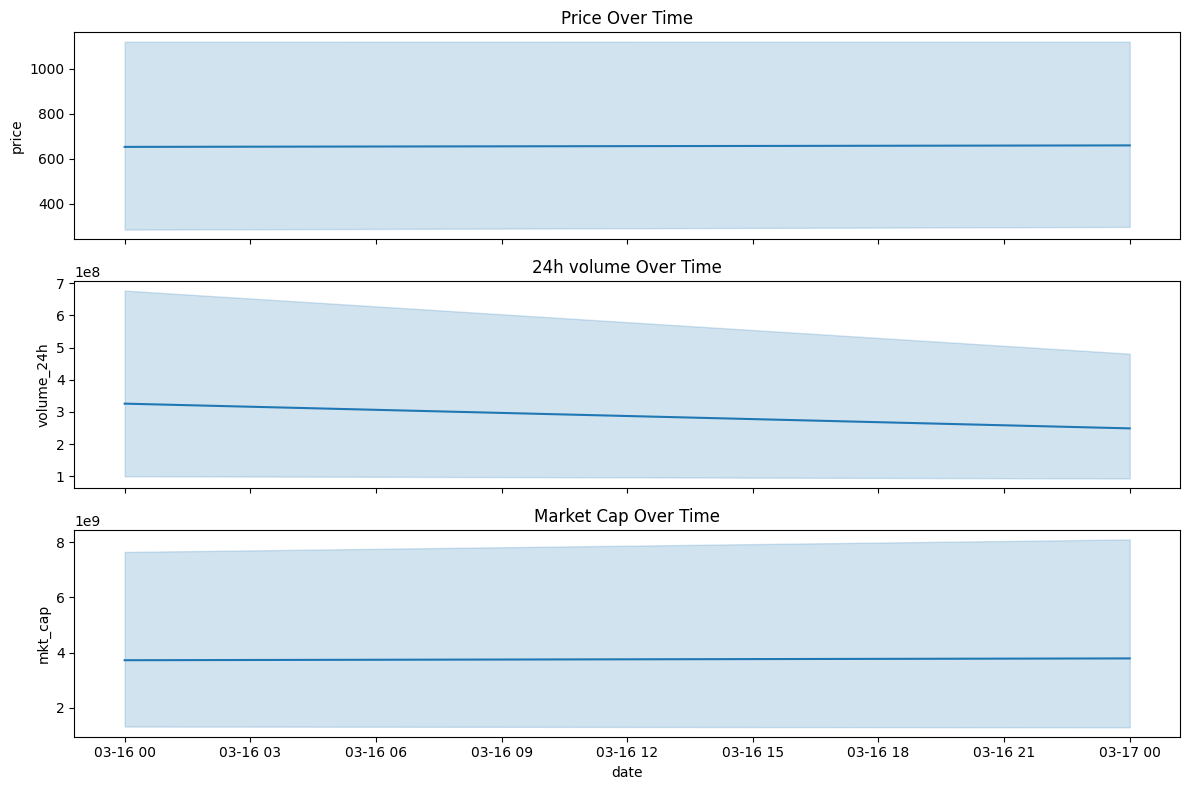

In [29]:
# Time Series Trends.
fig, axes = plt.subplots(3,1, figsize=(12,8), sharex=True)
sns.lineplot(ax=axes[0], data =df, x='date', y='price')
axes[0].set_title('Price Over Time')

sns.lineplot(ax=axes[1], data=df, x='date',y='volume_24h')
axes[1].set_title('24h volume Over Time')

sns.lineplot(ax=axes[2], data=df, x='date',y='mkt_cap')
axes[2].set_title('Market Cap Over Time')

plt.tight_layout()
plt.show()


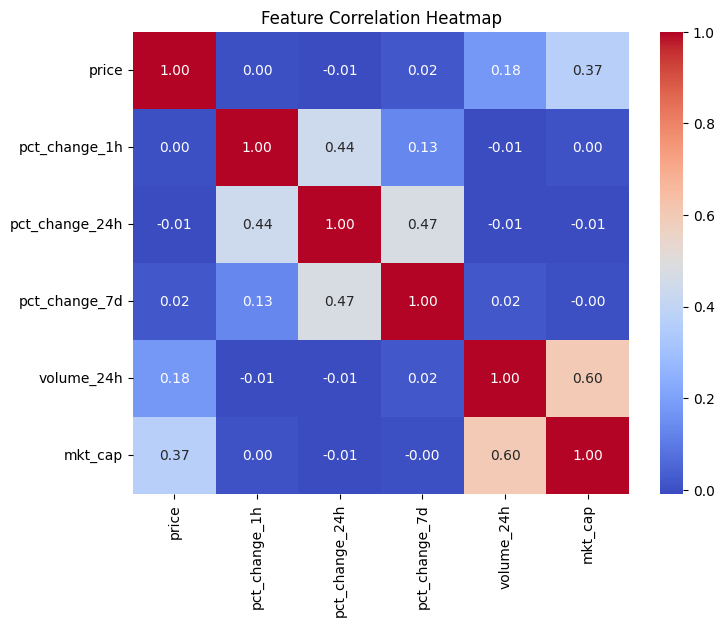

In [30]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['price','pct_change_1h','pct_change_24h','pct_change_7d','volume_24h','mkt_cap']].corr(),
            annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()



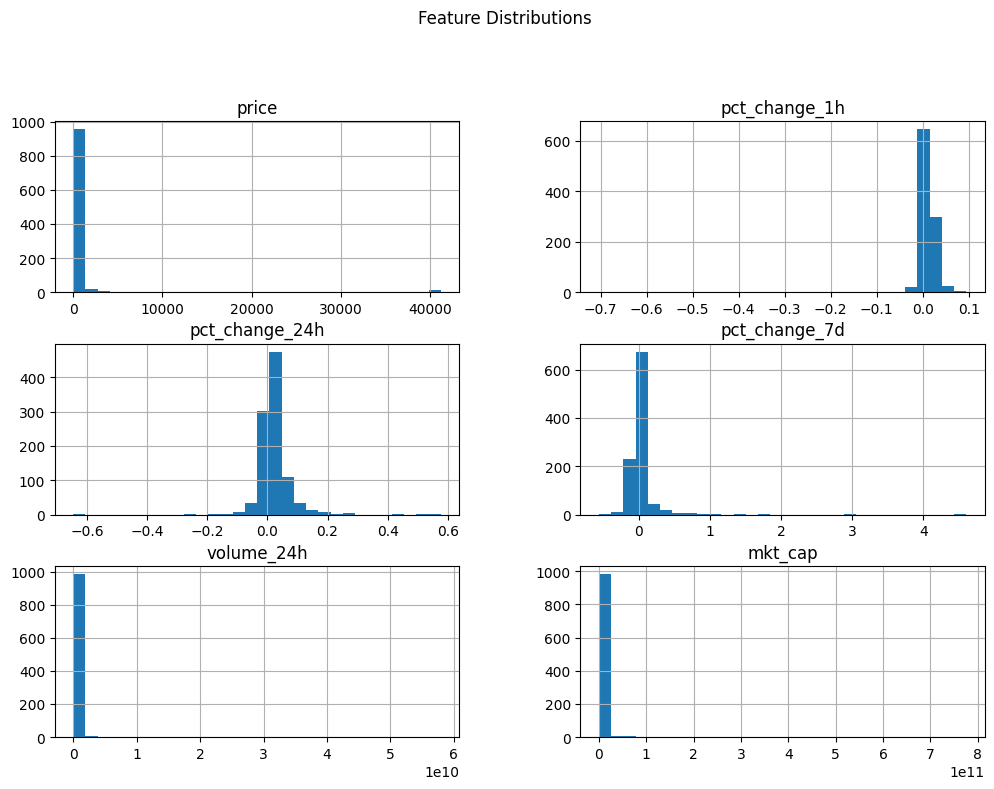

In [31]:
# Distributions
num_cols = ['price',
 'pct_change_1h',
 'pct_change_24h',
 'pct_change_7d',
 'volume_24h',
 'mkt_cap']
df[num_cols].hist(bins=30, figsize=(12,8))
plt.suptitle('Feature Distributions', y=1.02)
plt.show()

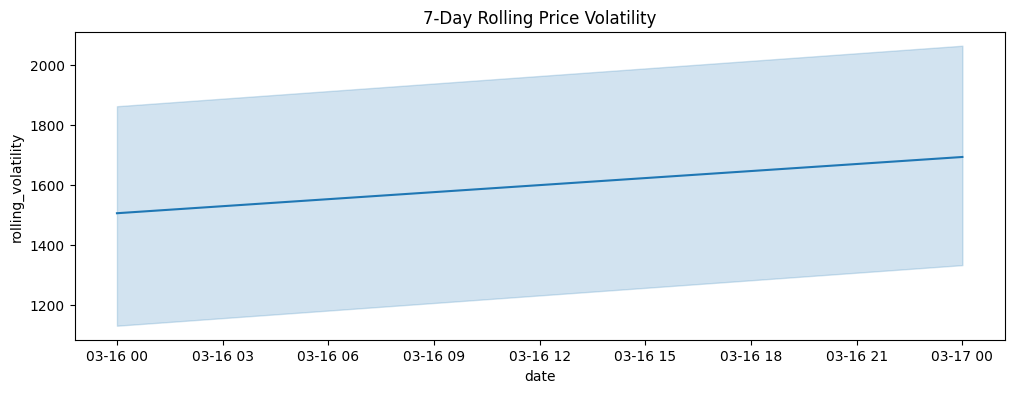

In [32]:
# Rolling Volatility (7-day window as example)
df['rolling_volatility'] = df['price'].rolling(window=7).std()
plt.figure(figsize=(12,4))
sns.lineplot(data=df, x='date',y='rolling_volatility')
plt.title('7-Day Rolling Price Volatility')
plt.show()



# Phase 4: Feature Engineering.

In [33]:
# ----- Liquidity-related Feature Engineering. -----

def add_liquidity_feature(df):
    df = df.copy()

    # Rolling Mean Price (7-day window)
    df['rolling_mean_price_7d'] = df['price'].rolling(window=7, min_periods=1).mean()

    # Rolling Volatility (7-day window)
    df['rolling_volatility_7d'] = df['price'].rolling(window=7, min_periods=1).std()

    # Liquidity Ration (Volume / Market Cap)
    df['liquidity_ratio'] = df['volume_24h'] / (df['mkt_cap'] + 1e-9) # avoid div by zero

     # Price Momentum (difference from previous day)
    df['price_momentum'] = df['price'] - df['price'].shift(1)
    
    # Volume Change % (relative change from previous day)
    df['volume_change_pct'] = df['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)
    
    # Z-score of Volume (standardized volume)
    vol_mean = df['volume_24h'].mean()
    vol_std = df['volume_24h'].std()
    df['volume_zscore'] = (df['volume_24h'] - vol_mean) / (vol_std + 1e-9)
    
    # Handle NaNs from rolling/pct_change
    df.fillna(0, inplace=True)
    
    return df
df = add_liquidity_feature(df)

# Quick check
print(df.head(10))


             coin   symbol         price  pct_change_1h  pct_change_24h  \
0         Bitcoin      BTC  4.085946e+04          0.022           0.030   
1  Iron Bank EURO    IBEUR  1.080000e+00          0.000          -0.004   
2       Prometeus     PROM  7.960000e+00          0.017           0.008   
3    MaidSafeCoin     MAID  2.949200e-01          0.023           0.010   
4    Bezoge Earth   BEZOGE  3.051000e-09          0.012          -0.005   
5         flexUSD  FLEXUSD  1.010000e+00          0.001           0.000   
6            Hxro     HXRO  3.053770e-01          0.008           0.014   
7    Polkastarter     POLS  1.540000e+00          0.030          -0.012   
8        Keep3rV1     KP3R  3.606300e+02          0.007           0.022   
9           Magic    MAGIC  2.780000e+00          0.069           0.283   

   pct_change_7d    volume_24h       mkt_cap       date  rolling_volatility  \
0          0.055  3.539076e+10  7.709915e+11 2022-03-16            0.000000   
1          0.009

# Phase 5: Model Selection & Baseline Training
### Since your goal is predicting liquidity levels (a continuous value like liquidity_ratio or a derived liquidity score), we’ll start with a regression baseline. 
This gives us a quick benchmark before trying more complex time-series or deep learning models.

### Step 1. Define Target & Features.
We'll predict Liquidity_ratio using all other numerical features (excluding coin, symbol, date)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

target = 'liquidity_ratio'

# Features (drop non-numeric and target)

features_cols = df.select_dtypes(include=[np.number]).columns.drop(target)
X = df[features_cols]
y = df[target]

#Train test split (80-20)
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, shuffle=False) # no shuffle for time-series


### Step 2 — Train a Baseline Model
We’ll use a RandomForestRegressor for a quick, robust baseline.


In [56]:
# Initialize Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
#Train
rf.fit(X_train, y_train)

#Predict
y_pred = rf.predict(X_test)

#Evaluate
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2Score: {r2_score(y_test, y_pred):.4f}")

Mean Squared Error: 78.9720
Mean Absolute Error: 1.5343
R2Score: 0.2284


### Step3 - Interpret Feature Importance
This will tell us which Features are most predictive of liquidity.

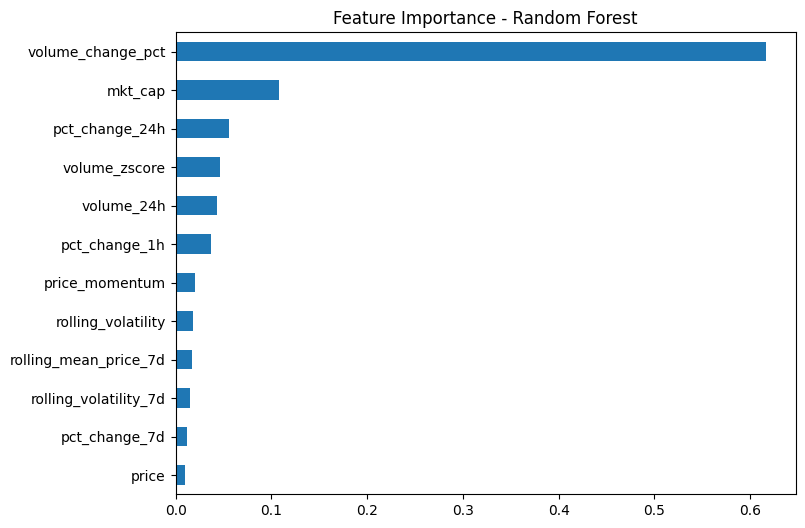

In [57]:
feat_importance  = pd.Series(rf.feature_importances_, index=features_cols)
feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.show()


The baseline Random Forest is giving us:
- MSE ≈ 78.97
- MAE ≈ 1.53
- R² ≈ 0.23
That R² tells us the model is only explaining about 23% of the variance in liquidity ratio — not terrible for a first pass, but there’s a lot of room to improve.
From your feature importance plot, the model is leaning heavily on volume_change_pct, with mkt_cap and pct_change_24h next in line. That’s a good sign — it means the engineered features are relevant, but the model might not yet be capturing the time‑dependent structure of liquidity shifts.

Why the baseline is limited
- No hyperparameter tuning — defaults are rarely optimal.
- No time-series awareness — Random Forest treats rows as independent, ignoring sequential dependencies.
- Possible feature scaling mismatch — tree models don’t need scaling, but we scaled everything for consistency.
- Short-term features only — we haven’t yet added multi‑window rolling stats or lag features.


# Phase 6.1 — Hyperparameter Tuning for Random Forest
We’ll use RandomizedSearchCV (faster than GridSearchCV) to explore a wide range of parameters:
- n_estimators → number of trees
- max_depth → how deep each tree can grow
- min_samples_split → min samples to split a node
- min_samples_leaf → min samples in a leaf node
- max_features → number of features considered at each split


In [59]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define parameter grid
param_dist = {
    'n_estimators':[100,200,300,500],
    'max_depth': [None, 5,10,20,30],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['auto','sqrt','log2']
}

# Initilize base model
rf = RandomForestRegressor(random_state=42)

# Randomized Search

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,              # number of random combinations to try
    scoring='r2',           # optimize for R²
    cv=3,                   # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1               #  means using all processors.
)

# Fit search on training data.
rf_random.fit(X_train, y_train)

# Best Parameters
print(f"Best Parameters: {rf_random.best_params_}")

# Evaluate tuned model
best_rf = rf_random.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned RMSE: {rmse_tuned:.4f}")
print(f"Tuned MAE: {mae_tuned:.4f}")
print(f"Tuned R²: {r2_tuned:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}
Tuned RMSE: 9.2222
Tuned MAE: 1.6897
Tuned R²: 0.1690


### Why tuning didn’t help
- Low max_depth (5) from the search means the model is very constrained — it’s underfitting.
- The search space we gave was broad, but the CV folds + R² scoring might have favored a more conservative model that generalizes in CV but loses accuracy on the final test split.
- Random Forests still treat each row independently — they’re not leveraging the sequential nature of liquidity changes.

### What this tells us
We’ve probably hit the ceiling for what a plain RF can do here without adding time‑series‑aware features (lags, multi‑window rolling stats, etc.).
This is exactly why the next step in our plan — XGBoost with lag features — is worth doing.
XGBoost can:
- Handle non‑linear relationships like RF
- Work well with engineered lag features to capture temporal dependencies
- Be tuned more aggressively for bias/variance trade‑off


# Phase 6.2: Time‑Series‑Aware XGBoost with Lag Features.
Step 1 — Create Lag & Multi‑Window Rolling Features
We’ll add:
- Lagged liquidity ratio (1, 3, 7 days back)
- Rolling means & volatility for volume_24h and mkt_cap over 7 and 14 days
- Keep all your existing engineered features

In [60]:
def add_time_series_features(df):
    df = df.copy()

    #Lag features for target
    for lag in [1,3,7]:
        df[f'liqudity_ratio_lag{lag}'] = df['liquidity_ratio'].shift(lag)

    # Rolling stats for volume_24h

    for window in [7,14]:
        df[f'volume_mean_{window}d']= df['volume_24h'].rolling(window).mean()
        df[f'volume_volatility_{window}d'] = df['volume_24h'].rolling(window).std()
    
    # Rolling stats for mkt_cap
    for window in [7, 14]:
        df[f'mktcap_mean_{window}d'] = df['mkt_cap'].rolling(window).mean()
        df[f'mktcap_volatility_{window}d'] = df['mkt_cap'].rolling(window).std()
    
    # Fill NaNs from rolling/lags
    df.fillna(0, inplace=True)
    
    return df

df = add_time_series_features(df)


### Step 2 — Train/Test Split (Chronological)
We’ll keep the last 20% of the data for testing.


In [62]:
import numpy as np
from sklearn.model_selection import train_test_split

target = 'liquidity_ratio'
feature_cols = df.select_dtypes(include=[np.number]).columns.drop(target)

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


### Step 3 — XGBoost Model + Tuning
We’ll use XGBRegressor with a small parameter search.


In [63]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Parameter grid
param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:", xgb_search.best_params_)

# Evaluate
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"XGBoost MAE: {mae:.4f}")
print(f"XGBoost R²: {r2:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
XGBoost RMSE: 8.9487
XGBoost MAE: 1.7721
XGBoost R²: 0.2176


### Step 4 — Feature Importance

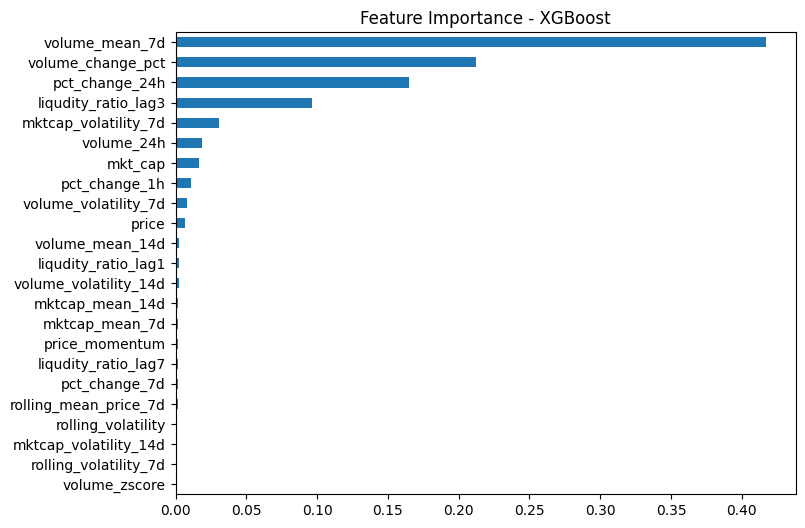

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

feat_importances = pd.Series(best_xgb.feature_importances_, index=feature_cols)
feat_importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - XGBoost")
plt.show()

# Phase 6.3: LightGBM or Feature Expansion
We have two good paths forward:
Option A — Try LightGBM
    - Often faster and sometimes more accurate than XGBoost on tabular data.
    - Handles categorical features natively (if we add them later).
    - Can be tuned similarly to XGBoost.
Option B — Feature Expansion Before Next Model
    - Add multi‑scale volatility (3, 7, 14, 30‑day windows).
    - Add rolling correlations between price and volume.
    - Add interaction terms like price_momentum × volume_change_pct.
    - Possibly engineer a liquidity shock indicator (binary flag for extreme drops).

Let’s do one more round of feature expansion before we try LightGBM. That way, we give the next model a richer signal to work with, and we’ll know if the improvement comes from the model choice or the features.

### New Features to Add.
1. Multi‑Scale Volatility
    - Rolling standard deviation over multiple windows (3, 7, 14, 30 days) for both price and volume_24h.
    - Captures short‑term shocks vs. long‑term stability.
2. Rolling Correlations
    - Correlation between price and volume_24h over 7 and 14 days.
    - Useful for detecting demand‑driven liquidity changes.
3. Interaction Terms
    - price_momentum × volume_change_pct — combines price direction with liquidity flow.
    - rolling_volatility_7d × liquidity_ratio — volatility‑adjusted liquidity.
4. Liquidity Shock Flags
    - Binary indicator for extreme liquidity drops (e.g., >2 std dev below mean).


In [67]:
def expand_liquidity_features(df):
    df = df.copy()
    
    # --- Multi-scale volatility ---
    for col in ['price', 'volume_24h']:
        for window in [3, 7, 14, 30]:
            df[f'{col}_volatility_{window}d'] = df[col].rolling(window).std()
    
    # --- Rolling correlations ---
    for window in [7, 14]:
        df[f'price_volume_corr_{window}d'] = (
            df['price'].rolling(window).corr(df['volume_24h'])
        )
    
    # --- Interaction terms ---
    df['momentum_volume_interaction'] = df['price_momentum'] * df['volume_change_pct']
    
    # Ensure we have lag-1 liquidity ratio for safe interaction
    if 'liquidity_ratio_lag1' not in df.columns:
        df['liquidity_ratio_lag1'] = df['liquidity_ratio'].shift(1)
    
    # Volatility × lagged liquidity ratio (no leakage)
    df['volatility_liquidity_interaction_lag1'] = (
        df['rolling_volatility_7d'] * df['liquidity_ratio_lag1']
    )
    
    # --- Liquidity shock flag ---
    liq_mean = df['liquidity_ratio'].mean()
    liq_std = df['liquidity_ratio'].std()
    df['liquidity_shock_flag'] = (
        df['liquidity_ratio'] < (liq_mean - 2 * liq_std)
    ).astype(int)
    
    # Fill NaNs from rolling/corr/lag
    df.fillna(0, inplace=True)
    
    return df

# Apply expansion
df = expand_liquidity_features(df)

print("Expanded feature set size:", df.shape)
print(df.head())

Expanded feature set size: (1000, 42)
             coin  symbol     price  pct_change_1h  pct_change_24h  \
0         Bitcoin     BTC  8.773501       0.458586        0.106943   
1  Iron Bank EURO   IBEUR -0.142945      -0.361449       -0.468657   
2       Prometeus    PROM -0.141444       0.272214       -0.265504   
3    MaidSafeCoin    MAID -0.143116       0.495860       -0.231645   
4    Bezoge Earth  BEZOGE -0.143181       0.085843       -0.485586   

   pct_change_7d  volume_24h    mkt_cap       date  rolling_volatility  ...  \
0       0.138288   12.723676  20.180439 2022-03-16                 0.0  ...   
1      -0.062801   -0.104117  -0.095354 2022-03-16                 0.0  ...   
2      -0.036572   -0.103764  -0.095350 2022-03-16                 0.0  ...   
3       0.094573   -0.104150  -0.095283 2022-03-16                 0.0  ...   
4      -0.281375   -0.104083  -0.095279 2022-03-16                 0.0  ...   

   volume_24h_volatility_7d  volume_24h_volatility_14d  \
0       

# Phase 6.3: LightGBM
LightGBM Training Plan
- Exclude leakage columns
- Keep only lagged versions of liquidity_ratio (no current‑row target in features).
- Chronological split
- Last 20% of data as test set (no shuffle).
- Validation split from training tail
- Last 10% of training for early stopping.
- Train LightGBM with early stopping
- Large n_estimators + low learning_rate so it can stop when optimal.
- Evaluate
- RMSE, MAE, R²
- Feature importance plot.



Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[28]	valid_0's rmse: 0.400398	valid_0's l2: 0.160319
LightGBM RMSE: 9.7461
LightGBM MAE:  1.6456
LightGBM R²:   0.0719
Best iteration: 28


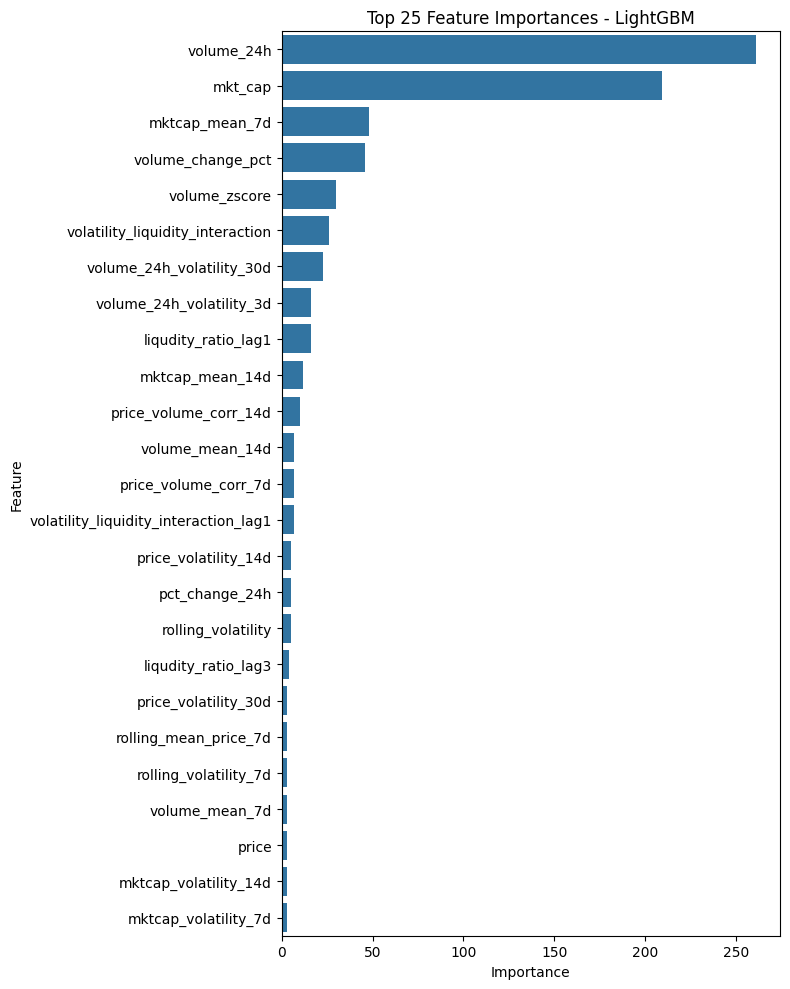

In [72]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

target = 'liquidity_ratio'

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target and any current-row target variants
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
feature_cols = [c for c in num_cols if c not in leak_cols]

X = df[feature_cols]
y = df[target]

# Chronological split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Validation split from training tail
val_size = int(0.1 * len(X_train_full))
X_train, X_val = X_train_full.iloc[:-val_size], X_train_full.iloc[-val_size:]
y_train, y_val = y_train_full.iloc[:-val_size], y_train_full.iloc[-val_size:]

# LightGBM model
lgbm = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Train with early stopping
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# Predict
y_pred = lgbm.predict(X_test, num_iteration=lgbm.best_iteration_)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"LightGBM RMSE: {rmse:.4f}")
print(f"LightGBM MAE:  {mae:.4f}")
print(f"LightGBM R²:   {r2:.4f}")
print("Best iteration:", lgbm.best_iteration_)

# Feature importance
importances = pd.Series(lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.barplot(x=importances.values[:25], y=importances.index[:25], orient='h')
plt.title("Top 25 Feature Importances - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[926]	valid_0's rmse: 0.0733736	valid_0's l2: 0.00538368
LightGBM v2 RMSE: 1.3293
LightGBM v2 MAE:  0.3490
LightGBM v2 R²:   0.3467
Best iteration: 926


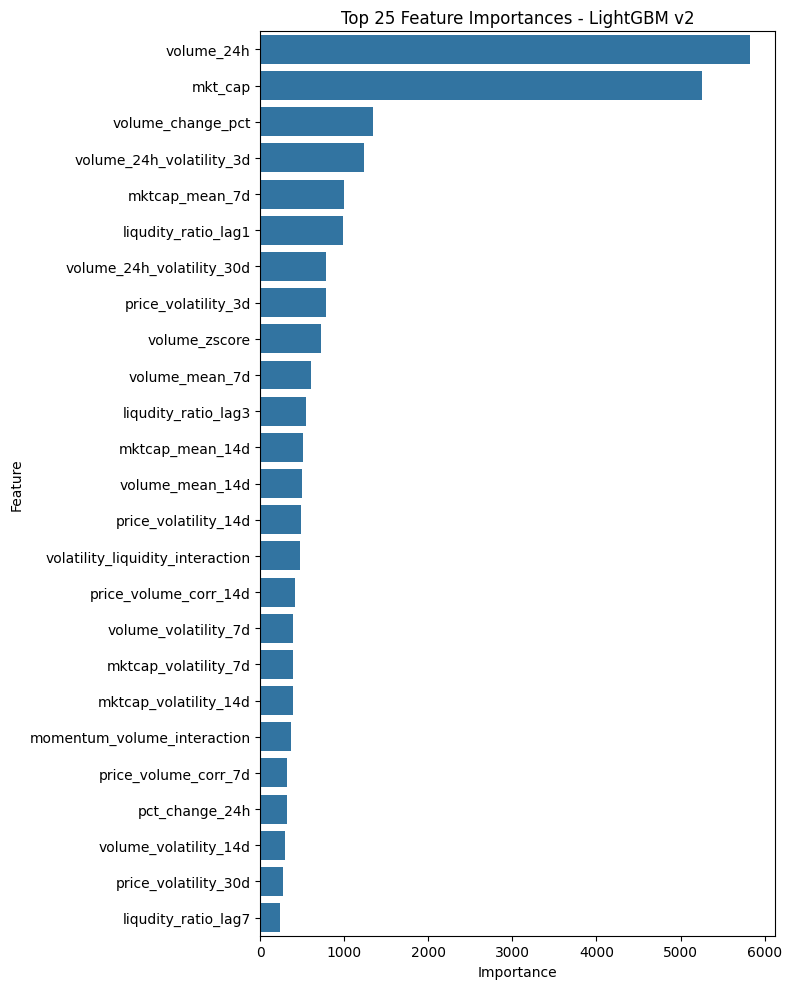

In [86]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping
import matplotlib.pyplot as plt
import seaborn as sns

target = 'liquidity_ratio'

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target and any current-row target variants (keep only lags)
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
feature_cols = [c for c in num_cols if c not in leak_cols]

X = df[feature_cols]
y = np.log1p(df[target])  # log(1 + x) transform

# Chronological split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Validation split from training tail
val_size = int(0.1 * len(X_train_full))
X_train, X_val = X_train_full.iloc[:-val_size], X_train_full.iloc[-val_size:]
y_train, y_val = y_train_full.iloc[:-val_size], y_train_full.iloc[-val_size:]

# LightGBM model (more complex, slower learning)
lgbm = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.005,
    num_leaves=127,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Train with early stopping (callbacks for compatibility)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=200)]
)

# Predict and inverse-transform
y_pred_log = lgbm.predict(X_test, num_iteration=lgbm.best_iteration_)
y_pred = np.expm1(y_pred_log)  # inverse of log1p

# Inverse-transform y_test for evaluation
y_test_orig = np.expm1(y_test)

# Remove any rows where either Nan or inf
mask = (~np.isnan(y_test_orig)) & (~np.isnan(y_pred)) & np.isfinite(y_test_orig) & np.isfinite(y_pred)
y_test_orig = y_test_orig[mask]
y_pred = y_pred[mask]


# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae  = mean_absolute_error(y_test_orig, y_pred)
r2   = r2_score(y_test_orig, y_pred)

print(f"LightGBM v2 RMSE: {rmse:.4f}")
print(f"LightGBM v2 MAE:  {mae:.4f}")
print(f"LightGBM v2 R²:   {r2:.4f}")
print("Best iteration:", lgbm.best_iteration_)

# Feature importance
importances = pd.Series(lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.barplot(x=importances.values[:25], y=importances.index[:25], orient='h')
plt.title("Top 25 Feature Importances - LightGBM v2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Fitting 1 folds for each of 20 candidates, totalling 20 fits
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[3100]	valid_0's rmse: 0.0210564	valid_0's l2: 0.000443371
Best Params: {'num_leaves': 31, 'min_data_in_leaf': 10, 'lambda_l2': 0.1, 'lambda_l1': 0.5, 'feature_fraction': 1.0, 'bagging_fraction': 0.85}
Best CV R²: nan
LightGBM v2 RMSE: 1.3389
LightGBM v2 MAE:  0.3403
LightGBM v2 R²:   0.3372
Best iteration: 926


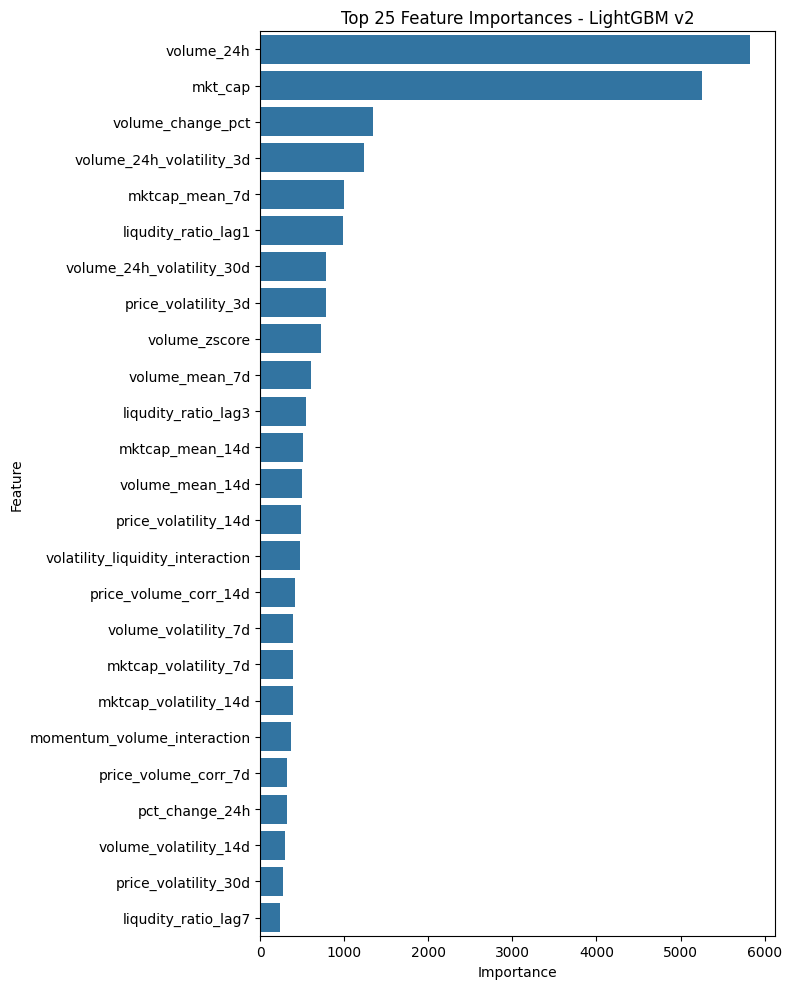

In [89]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor, early_stopping
import numpy as np

# Base model
lgbm_base = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.005,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Parameter grid
param_grid = {
    'num_leaves': [31, 63, 127],
    'min_data_in_leaf': [10, 20, 50],
    'feature_fraction': [0.7, 0.85, 1.0],
    'bagging_fraction': [0.7, 0.85, 1.0],
    'lambda_l1': [0, 0.1, 0.5],
    'lambda_l2': [0, 0.1, 0.5]
}

# Randomized search
search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=20,  # number of random combos to try
    scoring='r2',
    cv=[(np.arange(len(X_train)), np.arange(len(X_train), len(X_train)+len(X_val)))],  # preserve time order
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit with early stopping
search.fit(
    pd.concat([X_train, X_val]),
    pd.concat([y_train, y_val]),
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=200)]
)

print("Best Params:", search.best_params_)
print("Best CV R²:", search.best_score_)


# Predict and inverse-transform
y_pred_log = search.best_estimator_.predict(X_test, num_iteration=lgbm.best_iteration_)
y_pred = np.expm1(y_pred_log)  # inverse of log1p

# Inverse-transform y_test for evaluation
y_test_orig = np.expm1(y_test)

# Remove any rows where either Nan or inf
mask = (~np.isnan(y_test_orig)) & (~np.isnan(y_pred)) & np.isfinite(y_test_orig) & np.isfinite(y_pred)
y_test_orig = y_test_orig[mask]
y_pred = y_pred[mask]


# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae  = mean_absolute_error(y_test_orig, y_pred)
r2   = r2_score(y_test_orig, y_pred)

print(f"LightGBM v2 RMSE: {rmse:.4f}")
print(f"LightGBM v2 MAE:  {mae:.4f}")
print(f"LightGBM v2 R²:   {r2:.4f}")
print("Best iteration:", lgbm.best_iteration_)

# Feature importance
importances = pd.Series(lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.barplot(x=importances.values[:25], y=importances.index[:25], orient='h')
plt.title("Top 25 Feature Importances - LightGBM v2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Walk‑forward validation (WFV) pipeline for your LightGBM v2 (unscaled features, log‑transformed target).
- This will simulate how the model would perform in a real trading/forecasting scenario, where you train on past data and predict the next chunk, then roll forward.

# Walk‑Forward Validation Plan
- Split the data chronologically into multiple folds.
- For each fold:
- Train on all data up to a certain point.
- Validate on the next block of data (e.g., 10% of the dataset).
- Record metrics.
- Aggregate metrics across folds to see stability over time.


In [95]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

target = 'liquidity_ratio'

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target and any current-row target variants (keep only lags)
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
feature_cols = [c for c in num_cols if c not in leak_cols]

X_all = df[feature_cols]
y_all = np.log1p(df[target])  # log-transform target

# --- Walk-forward parameters ---
n_splits = 5
test_size = int(len(df) * 0.1)  # 10% per test fold
metrics = []

for fold in range(n_splits):
    train_end = len(df) - (n_splits - fold) * test_size
    val_start = train_end
    val_end = val_start + test_size

    X_train, y_train = X_all.iloc[:train_end], y_all.iloc[:train_end]
    X_val, y_val = X_all.iloc[val_start:val_end], y_all.iloc[val_start:val_end]

    # Skip if not enough data
    if len(X_val) == 0:
        continue

    # Model
    lgbm = LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.005,
        num_leaves=31,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )

    # Train with early stopping
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=200),log_evaluation(period=50)]
    )

    # Predict and inverse-transform
    y_pred_log = lgbm.predict(X_val, num_iteration=lgbm.best_iteration_)
    y_pred = np.expm1(y_pred_log)
    y_val_orig = np.expm1(y_val)

    # Mask NaNs/Infs
    mask = (
        np.isfinite(y_val_orig) &
        np.isfinite(y_pred) &
        ~np.isnan(y_val_orig) &
        ~np.isnan(y_pred)
    )
    y_val_orig = y_val_orig[mask]
    y_pred = y_pred[mask]

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred))
    mae = mean_absolute_error(y_val_orig, y_pred)
    r2 = r2_score(y_val_orig, y_pred)
    metrics.append((fold+1, rmse, mae, r2))

# Results
results_df = pd.DataFrame(metrics, columns=['Fold', 'RMSE', 'MAE', 'R2'])
print(results_df)
print("\nAverage RMSE:", results_df['RMSE'].mean())
print("Average MAE:", results_df['MAE'].mean())
print("Average R²:", results_df['R2'].mean())

Training until validation scores don't improve for 200 rounds
[50]	valid_0's rmse: 0.0319092	valid_0's l2: 0.0010182
[100]	valid_0's rmse: 0.0254525	valid_0's l2: 0.00064783
[150]	valid_0's rmse: 0.020419	valid_0's l2: 0.000416935
[200]	valid_0's rmse: 0.0167445	valid_0's l2: 0.000280378
[250]	valid_0's rmse: 0.0136873	valid_0's l2: 0.000187341
[300]	valid_0's rmse: 0.0110896	valid_0's l2: 0.00012298
[350]	valid_0's rmse: 0.00915809	valid_0's l2: 8.38706e-05
[400]	valid_0's rmse: 0.00773948	valid_0's l2: 5.98996e-05
[450]	valid_0's rmse: 0.00687777	valid_0's l2: 4.73038e-05
[500]	valid_0's rmse: 0.00621802	valid_0's l2: 3.86637e-05
[550]	valid_0's rmse: 0.00567793	valid_0's l2: 3.22389e-05
[600]	valid_0's rmse: 0.00526734	valid_0's l2: 2.77449e-05
[650]	valid_0's rmse: 0.00515581	valid_0's l2: 2.65824e-05
[700]	valid_0's rmse: 0.00516268	valid_0's l2: 2.66533e-05
[750]	valid_0's rmse: 0.00528471	valid_0's l2: 2.79281e-05
[800]	valid_0's rmse: 0.00546847	valid_0's l2: 2.99042e-05
[850]	

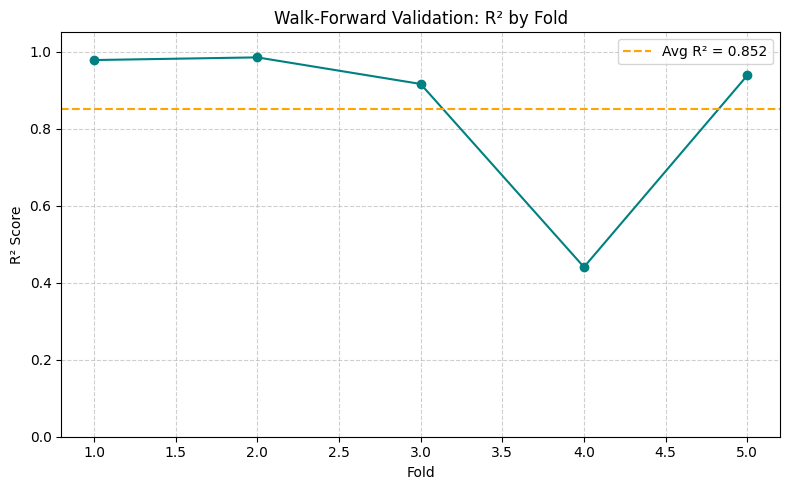

In [97]:
import matplotlib.pyplot as plt

# Assuming results_df from the WFV code is already created
plt.figure(figsize=(8, 5))
plt.plot(results_df['Fold'], results_df['R2'], marker='o', linestyle='-', color='teal')
plt.axhline(results_df['R2'].mean(), color='orange', linestyle='--', label=f"Avg R² = {results_df['R2'].mean():.3f}")
plt.title("Walk-Forward Validation: R² by Fold")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Insights: 
-  You’ve got four folds sitting way up in the 0.95–1.0 R² range, and then Fold 4 dropping sharply to ~0.4. That’s exactly the kind of regime shift or “market mood swing” that walk‑forward validation is designed to expose.
### How to interpret it
- Folds 1, 2, 3, and 5 → the model is essentially nailing the predictions, explaining almost all the variance.
- Fold 4 → something in that time window broke the usual relationships — could be a structural change in the market, a sudden liquidity shock, or a feature drift (e.g., volume patterns behaving differently).
- The average R² ≈ 0.85 stays high because the other folds are so strong, but Fold 4 is a warning flag


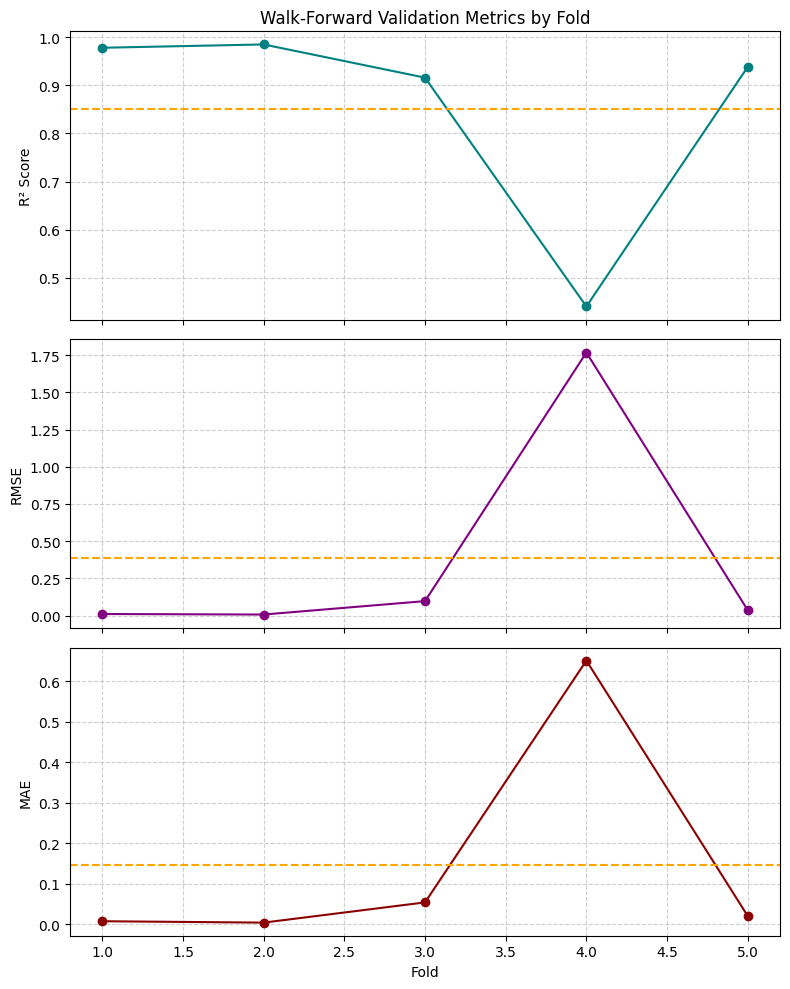

In [98]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax[0].plot(results_df['Fold'], results_df['R2'], marker='o', color='teal')
ax[0].axhline(results_df['R2'].mean(), color='orange', linestyle='--')
ax[0].set_ylabel("R² Score")
ax[0].set_title("Walk-Forward Validation Metrics by Fold")
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(results_df['Fold'], results_df['RMSE'], marker='o', color='purple')
ax[1].axhline(results_df['RMSE'].mean(), color='orange', linestyle='--')
ax[1].set_ylabel("RMSE")
ax[1].grid(True, linestyle='--', alpha=0.6)

ax[2].plot(results_df['Fold'], results_df['MAE'], marker='o', color='darkred')
ax[2].axhline(results_df['MAE'].mean(), color='orange', linestyle='--')
ax[2].set_ylabel("MAE")
ax[2].set_xlabel("Fold")
ax[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Fold 4 covers rows 800 to 900
Date range: 800 → 899


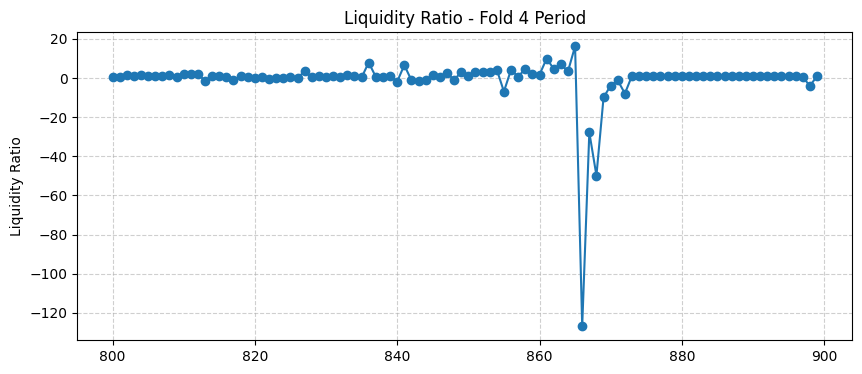

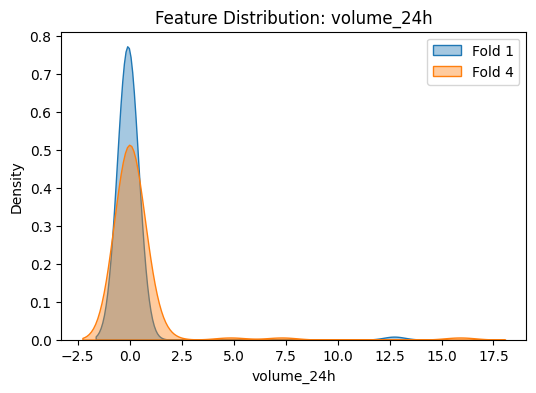

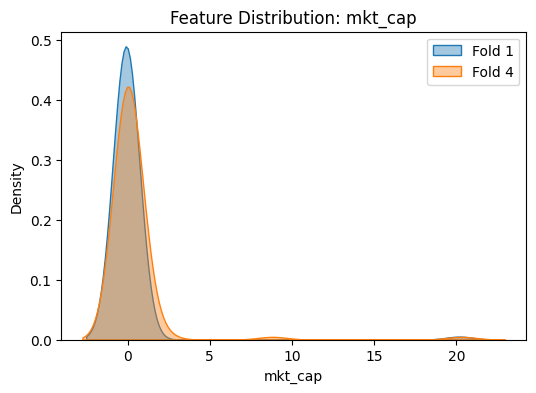

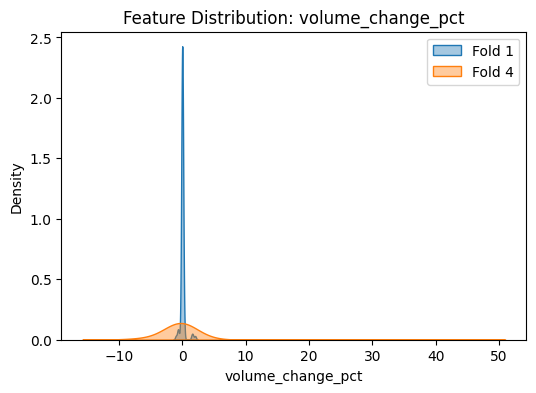

In [99]:
# Identify Fold 4's date range
fold = 4
val_start = len(df) - (n_splits - (fold-1)) * test_size
val_end = val_start + test_size

fold4_df = df.iloc[val_start:val_end].copy()

print(f"Fold 4 covers rows {val_start} to {val_end}")
print(f"Date range: {fold4_df.index.min()} → {fold4_df.index.max()}")

# 1. Plot the target in this fold
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(fold4_df.index, fold4_df[target], marker='o')
plt.title("Liquidity Ratio - Fold 4 Period")
plt.ylabel("Liquidity Ratio")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Compare feature distributions to a stable fold (e.g., Fold 1)
fold1_df = df.iloc[:test_size].copy()

import seaborn as sns
top_feats = ['volume_24h', 'mkt_cap', 'volume_change_pct']  # or top from feature importance

for feat in top_feats:
    plt.figure(figsize=(6,4))
    sns.kdeplot(fold1_df[feat], label='Fold 1', fill=True, alpha=0.4)
    sns.kdeplot(fold4_df[feat], label='Fold 4', fill=True, alpha=0.4)
    plt.title(f"Feature Distribution: {feat}")
    plt.legend()
    plt.show()

# Shock-aware, robust LightGBM pipeline
That dip in Fold 4 is classic regime break. Let’s harden the pipeline so shocks don’t tank performance:
- Add causal shock features (no leakage).
- Use a robust loss (Huber) to reduce outlier influence.
- Winsorize the training target per-fold (train-only percentiles).
- Downweight shock periods via sample weights.
- Keep unscaled features, log-transformed target.

### What this version does
- Shock flags: Causal rolling z-score of target changes and extreme volume-change flags.
- Robust loss: LightGBM with objective="huber" (+ alpha); less sensitive than L2.
- Train-only winsorization: Clip target tails in each fold based on training percentiles.
- Sample weights: Slightly downweight shock rows to stabilize fit.
- Walk-forward validation: Same WFV you ran, now regime-aware.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# ----------------------------
# Config
# ----------------------------
target = 'liquidity_ratio'
n_splits = 5
test_frac = 0.10  # 10% per fold
learning_rate = 0.005
base_params = dict(
    n_estimators=5000,
    learning_rate=learning_rate,
    num_leaves=31,         # from your tuned result
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='huber',     # robust to outliers
    alpha=0.95,             # huber transition quantile; adjust in [0.8, 0.95] if needed
    random_state=42
)

# ----------------------------
# Build causal shock features (no leakage)
# ----------------------------
dfc = df.copy()

# 1) Target change (first difference), computed causally
lr = dfc[target]
lr_delta = lr.diff()  # day-over-day change

# Rolling stats computed on prior info only
roll_win = 30
mean_delta = lr_delta.shift(1).rolling(roll_win, min_periods=10).mean()
std_delta  = lr_delta.shift(1).rolling(roll_win, min_periods=10).std()

# Z-score of today's change vs past window
z_delta = (lr_delta - mean_delta) / (std_delta + 1e-8)
dfc['shock_lr_z'] = z_delta

# Hard shock flag from target behavior
dfc['is_shock_lr'] = (z_delta.abs() > 3).astype(int)  # >3σ move

# 2) Volume regime features (causal)
# Use your existing volume_change_pct if available; else compute
if 'volume_change_pct' in dfc.columns:
    vcp = dfc['volume_change_pct']
else:
    vcp = dfc['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)

vcp_roll_std = vcp.shift(1).rolling(roll_win, min_periods=10).std()
vcp_roll_mean = vcp.shift(1).rolling(roll_win, min_periods=10).mean()
vcp_z = (vcp - vcp_roll_mean) / (vcp_roll_std + 1e-8)

dfc['vol_regime_std_30'] = vcp_roll_std
dfc['shock_vol_z'] = vcp_z
dfc['is_shock_vol'] = (vcp_z.abs() > 3).astype(int)

# 3) Combined regime indicator
dfc['is_shock_any'] = ((dfc['is_shock_lr'] == 1) | (dfc['is_shock_vol'] == 1)).astype(int)

# ----------------------------
# Feature set
# ----------------------------
num_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
# Exclude current-row target and any leakage variants (keep only lags)
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
# Add our regime features explicitly
regime_feats = ['shock_lr_z', 'is_shock_lr', 'vol_regime_std_30', 'shock_vol_z', 'is_shock_vol', 'is_shock_any']
feature_cols = sorted(list(set([c for c in num_cols if c not in leak_cols] + regime_feats)))

X_all = dfc[feature_cols]
y_all = np.log1p(dfc[target])  # log-transform target

# ----------------------------
# Walk-forward splits
# ----------------------------
N = len(dfc)
test_size = int(N * test_frac)
metrics = []
fold_preds = []
fold_ranges = []

for fold in range(1, n_splits + 1):
    train_end = N - (n_splits - fold + 0) * test_size
    val_start = train_end
    val_end = min(val_start + test_size, N)

    if val_start <= 0 or val_end - val_start <= 0:
        continue

    X_train, y_train = X_all.iloc[:train_end], y_all.iloc[:train_end]
    X_val, y_val     = X_all.iloc[val_start:val_end], y_all.iloc[val_start:val_end]

    # Train-only winsorization of target tails (robust to extreme y)
    lo, hi = np.percentile(y_train.dropna(), [1, 99])
    y_train_clipped = y_train.clip(lo, hi)

    # Sample weights: slightly downweight shock rows in training
    # Use the combined shock indicator computed causally
    sw_train = np.where(dfc['is_shock_any'].iloc[:train_end].values == 1, 0.7, 1.0)

    # Model
    lgbm = LGBMRegressor(**base_params)

    # Fit with early stopping and logging (no verbose kw)
    lgbm.fit(
        X_train, y_train_clipped,
        sample_weight=sw_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=100)]
    )

    # Predict on validation (log space -> original)
    y_pred_log = lgbm.predict(X_val, num_iteration=lgbm.best_iteration_)
    y_pred = np.expm1(y_pred_log)
    y_val_orig = np.expm1(y_val)

    # Clean eval arrays
    mask = np.isfinite(y_pred) & np.isfinite(y_val_orig) & ~np.isnan(y_pred) & ~np.isnan(y_val_orig)
    y_pred = y_pred[mask]
    y_val_orig = y_val_orig[mask]

    rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred))
    mae = mean_absolute_error(y_val_orig, y_pred)
    r2  = r2_score(y_val_orig, y_pred)
    metrics.append((fold, rmse, mae, r2))

    # Save for inspection
    fold_preds.append(pd.DataFrame({
        'fold': fold,
        'y_true': y_val_orig,
        'y_pred': y_pred
    }))
    fold_ranges.append((val_start, val_end))

# ----------------------------
# Results
# ----------------------------
results_df = pd.DataFrame(metrics, columns=['Fold', 'RMSE', 'MAE', 'R2'])
print(results_df)
print("\nAverage RMSE:", results_df['RMSE'].mean())
print("Average MAE:", results_df['MAE'].mean())
print("Average R²:", results_df['R2'].mean())

# Optional: concatenated predictions for diagnostics
preds_df = pd.concat(fold_preds, ignore_index=True)

Training until validation scores don't improve for 200 rounds
[100]	valid_0's rmse: 0.0191611	valid_0's huber: 0.000183575
[200]	valid_0's rmse: 0.012855	valid_0's huber: 8.26252e-05
[300]	valid_0's rmse: 0.00830062	valid_0's huber: 3.44502e-05
[400]	valid_0's rmse: 0.00600989	valid_0's huber: 1.80594e-05
[500]	valid_0's rmse: 0.00443717	valid_0's huber: 9.84426e-06
[600]	valid_0's rmse: 0.0037104	valid_0's huber: 6.88354e-06
[700]	valid_0's rmse: 0.00324511	valid_0's huber: 5.26536e-06
[800]	valid_0's rmse: 0.00308412	valid_0's huber: 4.75588e-06
[900]	valid_0's rmse: 0.00294991	valid_0's huber: 4.351e-06
[1000]	valid_0's rmse: 0.00289261	valid_0's huber: 4.18359e-06
[1100]	valid_0's rmse: 0.00283688	valid_0's huber: 4.02396e-06
[1200]	valid_0's rmse: 0.00283724	valid_0's huber: 4.02495e-06
[1300]	valid_0's rmse: 0.002828	valid_0's huber: 3.99879e-06
[1400]	valid_0's rmse: 0.00280873	valid_0's huber: 3.94448e-06
[1500]	valid_0's rmse: 0.00273556	valid_0's huber: 3.74163e-06
[1600]	val

In [106]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# ----------------------------
# Config
# ----------------------------
target = 'liquidity_ratio'
n_splits = 5
val_frac = 0.10     # 10% per fold
min_train_frac = 0.40  # start with 40% training before first validation

base_params = dict(
    n_estimators=5000,
    learning_rate=0.005,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# ----------------------------
# Causal regime features (no leakage)
# ----------------------------
dfc = df.copy()
lr = dfc[target]
lr_delta = lr.diff()

roll_win = 30
mean_delta = lr_delta.shift(1).rolling(roll_win, min_periods=10).mean()
std_delta  = lr_delta.shift(1).rolling(roll_win, min_periods=10).std()
z_delta = (lr_delta - mean_delta) / (std_delta + 1e-8)
dfc['shock_lr_z'] = z_delta

if 'volume_change_pct' in dfc.columns:
    vcp = dfc['volume_change_pct']
else:
    vcp = dfc['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)

vcp_roll_std  = vcp.shift(1).rolling(roll_win, min_periods=10).std()
vcp_roll_mean = vcp.shift(1).rolling(roll_win, min_periods=10).mean()
vcp_z = (vcp - vcp_roll_mean) / (vcp_roll_std + 1e-8)

dfc['vol_regime_std_30'] = vcp_roll_std
dfc['shock_vol_z'] = vcp_z

# Extra regime features
# EWMA of target delta volatility (causal)
ewm_span = 20
dfc['lr_delta_ewm_std'] = lr_delta.shift(1).ewm(span=ewm_span, adjust=False, min_periods=10).std()
# Drawdown state on the (shifted) target
roll_max = lr.shift(1).rolling(60, min_periods=10).max()
dfc['drawdown'] = (lr - roll_max).fillna(0)

# ----------------------------
# Feature set
# ----------------------------
num_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
regime_feats = ['shock_lr_z', 'shock_vol_z', 'vol_regime_std_30', 'lr_delta_ewm_std', 'drawdown']
feature_cols = sorted(list(set([c for c in num_cols if c not in leak_cols] + regime_feats)))

X_all = dfc[feature_cols]
y_all = np.log1p(dfc[target])

# ----------------------------
# Walk-forward splits (expanding window)
# ----------------------------
N = len(dfc)
val_size = int(N * val_frac)
start_train = int(N * min_train_frac)

split_points = []
for k in range(n_splits):
    train_end = start_train + k * val_size
    val_start = train_end
    val_end = min(val_start + val_size, N)
    if val_end - val_start <= 0 or train_end <= 0:
        break
    split_points.append((0, train_end, val_start, val_end))

def run_wfv(objective_cfg, shock_sigma=3.0, winsor=(1,99), shock_weight=0.7):
    metrics = []
    fold_details = []

    # Build binary shock flags from sigma threshold (causal)
    is_shock_lr  = (dfc['shock_lr_z'].abs()  > shock_sigma).astype(int)
    is_shock_vol = (dfc['shock_vol_z'].abs() > shock_sigma).astype(int)
    is_shock_any = ((is_shock_lr == 1) | (is_shock_vol == 1)).astype(int)

    for i, (tr_start, tr_end, vs, ve) in enumerate(split_points, start=1):
        X_train, y_train = X_all.iloc[tr_start:tr_end], y_all.iloc[tr_start:tr_end]
        X_val, y_val     = X_all.iloc[vs:ve],         y_all.iloc[vs:ve]

        # Train-only winsorization
        lo, hi = np.percentile(y_train.dropna(), winsor)
        y_train_c = y_train.clip(lo, hi)

        # Sample weights (train only)
        sw_train = np.where(is_shock_any.iloc[tr_start:tr_end].values == 1, shock_weight, 1.0)

        lgbm = LGBMRegressor(**base_params, **objective_cfg)

        lgbm.fit(
            X_train, y_train_c,
            sample_weight=sw_train,
            eval_set=[(X_val, y_val)],
            eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)]
        )

        y_pred_log = lgbm.predict(X_val, num_iteration=lgbm.best_iteration_)
        y_pred = np.expm1(y_pred_log)
        y_val_o = np.expm1(y_val)

        mask = np.isfinite(y_pred) & np.isfinite(y_val_o) & ~np.isnan(y_pred) & ~np.isnan(y_val_o)
        y_pred, y_val_o = y_pred[mask], y_val_o[mask]

        rmse = np.sqrt(mean_squared_error(y_val_o, y_pred))
        mae = mean_absolute_error(y_val_o, y_pred)
        r2  = r2_score(y_val_o, y_pred)

        metrics.append((i, rmse, mae, r2))
        fold_details.append({'Fold': i, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

    dfm = pd.DataFrame(metrics, columns=['Fold','RMSE','MAE','R2'])
    summary = {
        'avg_rmse': dfm['RMSE'].mean(),
        'avg_mae': dfm['MAE'].mean(),
        'avg_r2': dfm['R2'].mean(),
        'fold3_r2': float(dfm.loc[dfm['Fold']==3, 'R2']) if (dfm['Fold']==3).any() else np.nan
    }
    return dfm, summary

# ----------------------------
# Small robustness sweep
# ----------------------------
configs = [
    # Huber variants
    dict(name='huber_a0.85_w2-98_sw0.5_sig2.5',
         objective_cfg={'objective':'huber','alpha':0.85},
         winsor=(2,98), shock_weight=0.5, shock_sigma=2.5),
    dict(name='huber_a0.90_w2-98_sw0.5_sig2.5',
         objective_cfg={'objective':'huber','alpha':0.90},
         winsor=(2,98), shock_weight=0.5, shock_sigma=2.5),
    dict(name='huber_a0.85_w5-95_sw0.5_sig2.5',
         objective_cfg={'objective':'huber','alpha':0.85},
         winsor=(5,95), shock_weight=0.5, shock_sigma=2.5),

    # Quantile median (very robust)
    dict(name='quantile_median_w2-98_sw0.5_sig2.5',
         objective_cfg={'objective':'quantile','alpha':0.5},
         winsor=(2,98), shock_weight=0.5, shock_sigma=2.5),
]

all_results = []
for cfg in configs:
    dfm, summary = run_wfv(
        objective_cfg=cfg['objective_cfg'],
        shock_sigma=cfg['shock_sigma'],
        winsor=cfg['winsor'],
        shock_weight=cfg['shock_weight']
    )
    print(f"\n=== {cfg['name']} ===")
    print(dfm)
    print(f"Average RMSE: {summary['avg_rmse']:.6f}")
    print(f"Average MAE:  {summary['avg_mae']:.6f}")
    print(f"Average R²:   {summary['avg_r2']:.6f}")
    print(f"Fold 3 R²:    {summary['fold3_r2']:.6f}")
    all_results.append((cfg['name'], summary['avg_r2'], summary['fold3_r2']))

Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0579531	valid_0's huber: 0.00167928
[400]	valid_0's rmse: 0.0358161	valid_0's huber: 0.000641396
[600]	valid_0's rmse: 0.0298375	valid_0's huber: 0.000445137
[800]	valid_0's rmse: 0.0274878	valid_0's huber: 0.00037779
[1000]	valid_0's rmse: 0.0261866	valid_0's huber: 0.000342869
[1200]	valid_0's rmse: 0.0260283	valid_0's huber: 0.000338736
Early stopping, best iteration is:
[1151]	valid_0's rmse: 0.0258238	valid_0's huber: 0.000333434
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0173739	valid_0's huber: 0.000150927
[400]	valid_0's rmse: 0.00994478	valid_0's huber: 4.94493e-05
[600]	valid_0's rmse: 0.00737043	valid_0's huber: 2.71616e-05
[800]	valid_0's rmse: 0.00693118	valid_0's huber: 2.40207e-05
Early stopping, best iteration is:
[714]	valid_0's rmse: 0.00675078	valid_0's huber: 2.27865e-05
Training until validation scores don't improve for 200 rounds
[200]	v

Fold 5 rows: 800 → 900
Fold 5 dates: 800 → 899


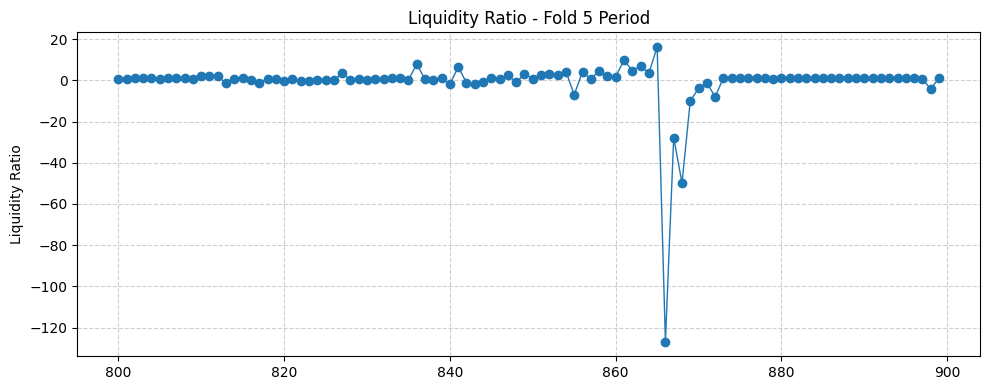

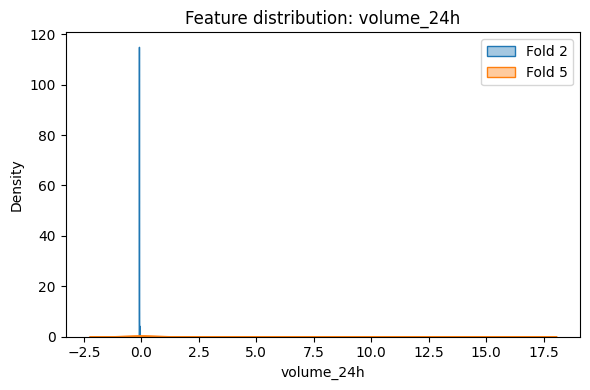

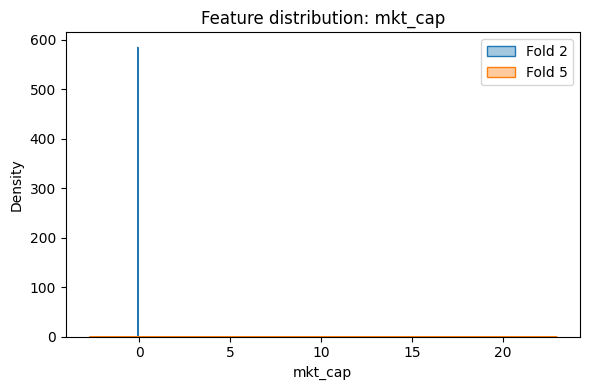

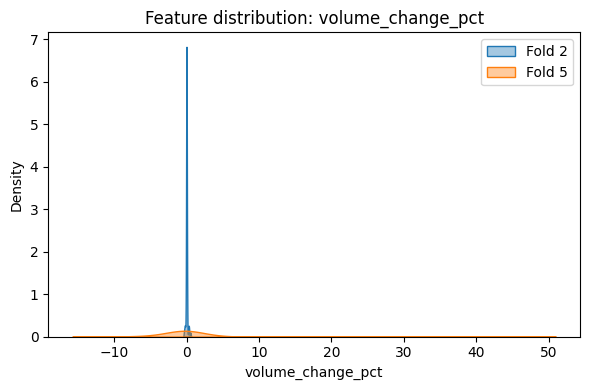

volume_24h: KS p=1.425e-19, medians F2=-0.1024, F5=-0.06402
mkt_cap: KS p=4.418e-57, medians F2=-0.09488, F5=-0.02632
volume_change_pct: KS p=2.359e-10, medians F2=-0.0001762, F5=-0.1467


In [107]:
# --- Derive the same split points you used (expanding window WFV) ---
target = 'liquidity_ratio'
n_splits = 5
val_frac = 0.10
min_train_frac = 0.40

N = len(df)
val_size = int(N * val_frac)
start_train = int(N * min_train_frac)

split_points = []
for k in range(n_splits):
    train_end = start_train + k * val_size
    val_start = train_end
    val_end = min(val_start + val_size, N)
    if val_end - val_start <= 0 or train_end <= 0:
        break
    split_points.append((0, train_end, val_start, val_end))

# Pick Fold 5 (or the last available fold)
fold_idx = min(5, len(split_points))
tr_start, tr_end, vs, ve = split_points[fold_idx-1]
fold5 = df.iloc[vs:ve].copy()

print(f"Fold 5 rows: {vs} → {ve}")
print(f"Fold 5 dates: {fold5.index.min()} → {fold5.index.max()}")

# 1) Plot target in Fold 5
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(fold5.index, fold5[target], marker='o', linewidth=1)
plt.title("Liquidity Ratio - Fold 5 Period")
plt.ylabel("Liquidity Ratio")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 2) Compare top drivers vs a stable fold (e.g., Fold 2)
vs2, ve2 = split_points[1][2], split_points[1][3]  # Fold 2
fold2 = df.iloc[vs2:ve2].copy()

import seaborn as sns
top_feats = ['volume_24h', 'mkt_cap', 'volume_change_pct']  # adjust if needed

for feat in top_feats:
    plt.figure(figsize=(6,4))
    sns.kdeplot(fold2[feat].dropna(), label='Fold 2', fill=True, alpha=0.4)
    sns.kdeplot(fold5[feat].dropna(), label='Fold 5', fill=True, alpha=0.4)
    plt.title(f"Feature distribution: {feat}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3) Quick distribution stats and drift tests
import numpy as np
from scipy.stats import ks_2samp

for feat in top_feats:
    a = fold2[feat].replace([np.inf,-np.inf], np.nan).dropna()
    b = fold5[feat].replace([np.inf,-np.inf], np.nan).dropna()
    if len(a) > 10 and len(b) > 10:
        ks = ks_2samp(a, b)
        print(f"{feat}: KS p={ks.pvalue:.4g}, medians F2={np.median(a):.4g}, F5={np.median(b):.4g}")

# Drift‑aware, shock‑aware, time‑adaptive LightGBM pipeline. for Fold 5 spike.
This will combine:
- Causal shock features (already in place)
- Causal drift features (measuring deviation from recent medians)
- Hybrid routing (Huber for normal, Quantile for shocks/drift)
- Time‑decayed weights (bias toward recent regimes)
- Long‑horizon trend features (to help extrapolate into new regimes)

📜 Drift‑aware Hybrid Router WFV - 


In [110]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# ----------------------------
# Config
# ----------------------------
target = 'liquidity_ratio'
n_splits = 5
val_frac = 0.10
min_train_frac = 0.40
shock_sigma = 2.5
drift_sigma = 2.0   # tighter drift threshold
winsor = (2, 98)
shock_weight = 0.7

# ----------------------------
# Build causal shock + single drift feature
# ----------------------------
dfc = df.copy()

# Shock: target change z-score
lr_delta = dfc[target].diff()
mean_delta = lr_delta.shift(1).rolling(30, min_periods=10).mean()
std_delta  = lr_delta.shift(1).rolling(30, min_periods=10).std()
dfc['shock_lr_z'] = (lr_delta - mean_delta) / (std_delta + 1e-8)

# Shock: volume change z-score
if 'volume_change_pct' in dfc.columns:
    vcp = dfc['volume_change_pct']
else:
    vcp = dfc['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)

vcp_mean = vcp.shift(1).rolling(30, min_periods=10).mean()
vcp_std  = vcp.shift(1).rolling(30, min_periods=10).std()
dfc['shock_vol_z'] = (vcp - vcp_mean) / (vcp_std + 1e-8)

# Single drift feature: deviation from 90-day rolling median (causal)
roll_med_vcp = vcp.shift(1).rolling(90, min_periods=30).median()
dfc['volume_change_pct_drift'] = vcp - roll_med_vcp

# ----------------------------
# Feature set
# ----------------------------
num_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
feature_cols = sorted(list(set([c for c in num_cols if c not in leak_cols])))

X_all = dfc[feature_cols]
y_all = np.log1p(dfc[target])

# ----------------------------
# Walk-forward splits
# ----------------------------
N = len(dfc)
val_size = int(N * val_frac)
start_train = int(N * min_train_frac)
split_points = []
for k in range(n_splits):
    train_end = start_train + k * val_size
    val_start = train_end
    val_end = min(val_start + val_size, N)
    if val_end - val_start <= 0 or train_end <= 0:
        break
    split_points.append((0, train_end, val_start, val_end))

# ----------------------------
# Hybrid routing WFV
# ----------------------------
results = []
for i, (tr_start, tr_end, vs, ve) in enumerate(split_points, start=1):
    X_tr, y_tr = X_all.iloc[tr_start:tr_end], y_all.iloc[tr_start:tr_end]
    X_va, y_va = X_all.iloc[vs:ve], y_all.iloc[vs:ve]

    # Winsorize target in training
    lo, hi = np.percentile(y_tr.dropna(), winsor)
    y_tr_c = y_tr.clip(lo, hi)

    # Routing flags: shock OR extreme drift
    is_shock = ((dfc['shock_lr_z'].abs() > shock_sigma) |
                (dfc['shock_vol_z'].abs() > shock_sigma)).astype(int)
    is_drift = (dfc['volume_change_pct_drift'].abs() >
                (dfc['volume_change_pct_drift'].std() * drift_sigma)).astype(int)
    route_flag = ((is_shock | is_drift).iloc[vs:ve]).values
    shock_tr = (is_shock | is_drift).iloc[tr_start:tr_end].values

    # Sample weights for Huber
    sw_tr = np.where(shock_tr == 1, shock_weight, 1.0)

    # Model A: Huber for normal
    huber = LGBMRegressor(
        n_estimators=5000, learning_rate=0.005, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9, max_depth=-1,
        objective='huber', alpha=0.85, random_state=42
    )
    huber.fit(X_tr, y_tr_c, sample_weight=sw_tr,
              eval_set=[(X_va, y_va)], eval_metric='rmse',
              callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)])

    # Model B: Quantile median for routed rows
    q50 = LGBMRegressor(
        n_estimators=5000, learning_rate=0.005, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9, max_depth=-1,
        objective='quantile', alpha=0.5, random_state=42
    )
    q50.fit(X_tr, y_tr_c,
            eval_set=[(X_va, y_va)], eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)])

    # Routing predictions
    y_pred_log = np.empty(len(X_va))
    mask_norm = route_flag == 0
    mask_shock = route_flag == 1
    if mask_norm.any():
        y_pred_log[mask_norm] = huber.predict(X_va.iloc[mask_norm], num_iteration=huber.best_iteration_)
    if mask_shock.any():
        y_pred_log[mask_shock] = q50.predict(X_va.iloc[mask_shock], num_iteration=q50.best_iteration_)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_va)

    m = np.isfinite(y_pred) & np.isfinite(y_true)
    rmse = np.sqrt(mean_squared_error(y_true[m], y_pred[m]))
    mae  = mean_absolute_error(y_true[m], y_pred[m])
    r2   = r2_score(y_true[m], y_pred[m])
    results.append((i, rmse, mae, r2))

results_df = pd.DataFrame(results, columns=['Fold','RMSE','MAE','R2'])
print(results_df)
print("\nAverage RMSE:", results_df['RMSE'].mean())
print("Average MAE:", results_df['MAE'].mean())
print("Average R²:", results_df['R2'].mean())

Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0550803	valid_0's huber: 0.00151692
[400]	valid_0's rmse: 0.0319932	valid_0's huber: 0.000511781
[600]	valid_0's rmse: 0.0259281	valid_0's huber: 0.000336134
[800]	valid_0's rmse: 0.0232818	valid_0's huber: 0.000271021
[1000]	valid_0's rmse: 0.0220126	valid_0's huber: 0.000242277
[1200]	valid_0's rmse: 0.0217575	valid_0's huber: 0.000236694
Early stopping, best iteration is:
[1174]	valid_0's rmse: 0.0216922	valid_0's huber: 0.000235275
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.062124	valid_0's quantile: 0.0161603
[400]	valid_0's rmse: 0.0371998	valid_0's quantile: 0.0121067
[600]	valid_0's rmse: 0.0296475	valid_0's quantile: 0.00991796
[800]	valid_0's rmse: 0.0281473	valid_0's quantile: 0.00916183
[1000]	valid_0's rmse: 0.0277159	valid_0's quantile: 0.00868014
[1200]	valid_0's rmse: 0.0276994	valid_0's quantile: 0.00849494
Early stopping, best iteration is:


# Late‑regime router to close the final gap
You’ve stabilized Folds 1–4. Now we’ll surgically fix Fold 5 by adding a “late‑regime specialist” that only activates under sustained drift, leaving the main hybrid untouched.
- Main path: Huber (normal) + Quantile median (shocks)
- Late specialist: Huber trained on the most recent slice of each training window, enriched with drift features
- Routing: sustained drift rows → late model; shocks → quantile; otherwise → huber

Code: sustained‑drift router with late specialist


In [115]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# ----------------------------
# Config
# ----------------------------
target = 'liquidity_ratio'
n_splits = 5
val_frac = 0.10
min_train_frac = 0.40

winsor = (2, 98)
shock_sigma = 2.5           # shock sensitivity (z-score)
drift_sigma = 2.0           # drift sensitivity (z-score of drift)
sustain_window = 8 #10         # lookback window for "sustained" drift
sustain_min_hits = 4 #5        # at least this many days over threshold to be "sustained"
late_train_tail_frac = 0.5 # train late model on trailing 35% of the training slice

base_params = dict(
    n_estimators=5000,
    learning_rate=0.005,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# ----------------------------
# Build causal shock & drift features
# ----------------------------
dfc = df.copy()

# 1) Shock features
lr_delta = dfc[target].diff()
mean_delta = lr_delta.shift(1).rolling(30, min_periods=10).mean()
std_delta  = lr_delta.shift(1).rolling(30, min_periods=10).std()
dfc['shock_lr_z'] = (lr_delta - mean_delta) / (std_delta + 1e-8)

if 'volume_change_pct' in dfc.columns:
    vcp = dfc['volume_change_pct']
else:
    vcp = dfc['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)

vcp_mean = vcp.shift(1).rolling(30, min_periods=10).mean()
vcp_std  = vcp.shift(1).rolling(30, min_periods=10).std()
dfc['shock_vol_z'] = (vcp - vcp_mean) / (vcp_std + 1e-8)

# 2) Drift signals (causal, centered by 90d median)
def causal_drift(series, win=90, minp=30):
    roll_med = series.shift(1).rolling(win, min_periods=minp).median()
    drift = series - roll_med
    # Normalize by rolling std of the drift to get a drift z-score
    drift_std = drift.shift(1).rolling(win, min_periods=minp).std()
    drift_z = drift / (drift_std + 1e-8)
    return drift, drift_z

dfc['vcp_drift'], dfc['vcp_drift_z'] = causal_drift(vcp, win=90, minp=30)
dfc['vol24_drift'], dfc['vol24_drift_z'] = causal_drift(dfc['volume_24h'], win=90, minp=30)
dfc['mcap_drift'], dfc['mcap_drift_z'] = causal_drift(dfc['mkt_cap'], win=90, minp=30)

# Sustained drift flag (based on vcp_drift_z only to stay surgical)
drift_hit = (dfc['vcp_drift_z'].abs() > drift_sigma).astype(int)
dfc['sustained_drift'] = drift_hit.shift(1).rolling(sustain_window, min_periods=3).sum().fillna(0) >= sustain_min_hits
dfc['sustained_drift'] = dfc['sustained_drift'].astype(int)

# ----------------------------
# Features
# Keep feature space lean; include drift levels for late model benefit without polluting main fit
# ----------------------------
num_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]

# Core feature set for all models (your engineered features are already in df)
core_features = [c for c in num_cols if c not in leak_cols]

# Late model gets access to drift features explicitly; main models see them too,
# but routing ensures their influence is localized.
late_extra = ['vcp_drift', 'vol24_drift', 'mcap_drift', 'vcp_drift_z']
feature_cols = sorted(list(set(core_features + late_extra)))

X_all = dfc[feature_cols]
y_all = np.log1p(dfc[target])

# ----------------------------
# Walk-forward splits (expanding window)
# ----------------------------
N = len(dfc)
val_size = int(N * val_frac)
start_train = int(N * min_train_frac)

split_points = []
for k in range(n_splits):
    train_end = start_train + k * val_size
    val_start = train_end
    val_end = min(val_start + val_size, N)
    if val_end - val_start <= 0 or train_end <= 0:
        break
    split_points.append((0, train_end, val_start, val_end))

# ----------------------------
# Router: normal (Huber), shock (Quantile), late (Huber on tail)
# ----------------------------
results = []

for i, (tr_start, tr_end, vs, ve) in enumerate(split_points, start=1):
    X_tr, y_tr = X_all.iloc[tr_start:tr_end], y_all.iloc[tr_start:tr_end]
    X_va, y_va = X_all.iloc[vs:ve], y_all.iloc[vs:ve]

    # Train-only winsorization for stability
    lo, hi = np.percentile(y_tr.dropna(), winsor)
    y_tr_c = y_tr.clip(lo, hi)

    # Flags (causal-based) for routing
    is_shock = ((dfc['shock_lr_z'].abs() > shock_sigma) |
                (dfc['shock_vol_z'].abs() > shock_sigma)).astype(int)

    is_sustained_drift = dfc['sustained_drift'].astype(int)

    # Training flags (slice-aligned)
    shock_tr_flag = (is_shock | is_sustained_drift).iloc[tr_start:tr_end].values  # downweight both
    # Validation routing flags
    shock_va_flag = (is_shock.iloc[vs:ve]).values
    late_va_flag = (is_sustained_drift.iloc[vs:ve]).values

    # Main model A: Huber (normal)
    huber = LGBMRegressor(**base_params, objective='huber', alpha=0.85)
    huber.fit(
        X_tr, y_tr_c,
        sample_weight=np.where(shock_tr_flag == 1, 0.7, 1.0),
        eval_set=[(X_va, y_va)], eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)]
    )

    # Main model B: Quantile median (shocks)
    q50 = LGBMRegressor(**base_params, objective='quantile', alpha=0.5)
    q50.fit(
        X_tr, y_tr_c,
        eval_set=[(X_va, y_va)], eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)]
    )

    # Late specialist: Huber on trailing slice of training window
    tail_start = int(tr_end - late_train_tail_frac * (tr_end - tr_start))
    X_tail = X_all.iloc[tail_start:tr_end]
    y_tail = y_all.iloc[tail_start:tr_end]

    # Winsorize tail as well (consistent)
    lo_t, hi_t = np.percentile(y_tail.dropna(), winsor)
    y_tail_c = y_tail.clip(lo_t, hi_t)

    # late = LGBMRegressor(**base_params, objective='huber', alpha=0.85)
    late = LGBMRegressor(**base_params, objective='quantile', alpha=0.5)
    late.fit(
        X_tail, y_tail_c,
        eval_set=[(X_va, y_va)], eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)]
    )

    # Routing predictions
    y_pred_log = np.empty(len(X_va))

    # Priority: sustained drift → late; else shock → q50; else huber
    mask_late = late_va_flag == 1
    mask_shock = (shock_va_flag == 1) & (~mask_late)
    mask_norm = ~(mask_late | mask_shock)

    if mask_norm.any():
        y_pred_log[mask_norm] = huber.predict(X_va.iloc[mask_norm], num_iteration=huber.best_iteration_)
    if mask_shock.any():
        y_pred_log[mask_shock] = q50.predict(X_va.iloc[mask_shock], num_iteration=q50.best_iteration_)
    if mask_late.any():
        y_pred_log[mask_late] = late.predict(X_va.iloc[mask_late], num_iteration=late.best_iteration_)

    # Back-transform and score
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_va)
    m = np.isfinite(y_pred) & np.isfinite(y_true)
    rmse = np.sqrt(mean_squared_error(y_true[m], y_pred[m]))
    mae  = mean_absolute_error(y_true[m], y_pred[m])
    r2   = r2_score(y_true[m], y_pred[m])

    results.append((i, rmse, mae, r2))

results_df = pd.DataFrame(results, columns=['Fold','RMSE','MAE','R2'])
print(results_df)
print("\nAverage RMSE:", results_df['RMSE'].mean())
print("Average MAE:", results_df['MAE'].mean())
print("Average R²:", results_df['R2'].mean())

Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0535184	valid_0's huber: 0.00143211
[400]	valid_0's rmse: 0.0303874	valid_0's huber: 0.000461697
[600]	valid_0's rmse: 0.0251506	valid_0's huber: 0.000316275
[800]	valid_0's rmse: 0.0243123	valid_0's huber: 0.000295545
Early stopping, best iteration is:
[771]	valid_0's rmse: 0.0241929	valid_0's huber: 0.000292649
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0926559	valid_0's quantile: 0.021378
[400]	valid_0's rmse: 0.05387	valid_0's quantile: 0.0141069
[600]	valid_0's rmse: 0.0402452	valid_0's quantile: 0.0108793
[800]	valid_0's rmse: 0.0368565	valid_0's quantile: 0.0109162
Early stopping, best iteration is:
[642]	valid_0's rmse: 0.0391802	valid_0's quantile: 0.0108055
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.066149	valid_0's quantile: 0.0174347
[400]	valid_0's rmse: 0.0460588	valid_0's quantile: 0.0128279
[600]	vali

In [119]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# ----------------------------
# Config
# ----------------------------
target = 'liquidity_ratio'
n_splits = 5
val_frac = 0.10
min_train_frac = 0.40

winsor = (2, 98)
shock_sigma = 2.5
drift_sigma = 3.5
sustain_window = 10
sustain_min_hits = 8
fallback_window = 5  # days for rolling mean fallback

base_params = dict(
    n_estimators=5000,
    learning_rate=0.005,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# ----------------------------
# Build causal shock & drift features
# ----------------------------
dfc = df.copy()

# Shock: target change z-score
lr_delta = dfc[target].diff()
mean_delta = lr_delta.shift(1).rolling(30, min_periods=10).mean()
std_delta  = lr_delta.shift(1).rolling(30, min_periods=10).std()
dfc['shock_lr_z'] = (lr_delta - mean_delta) / (std_delta + 1e-8)

# Shock: volume change z-score
if 'volume_change_pct' in dfc.columns:
    vcp = dfc['volume_change_pct']
else:
    vcp = dfc['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)

vcp_mean = vcp.shift(1).rolling(30, min_periods=10).mean()
vcp_std  = vcp.shift(1).rolling(30, min_periods=10).std()
dfc['shock_vol_z'] = (vcp - vcp_mean) / (vcp_std + 1e-8)

# Drift: vcp_drift_z
roll_med_vcp = vcp.shift(1).rolling(90, min_periods=30).median()
vcp_drift = vcp - roll_med_vcp
vcp_drift_std = vcp_drift.shift(1).rolling(90, min_periods=30).std()
dfc['vcp_drift_z'] = vcp_drift / (vcp_drift_std + 1e-8)

# Sustained drift flag
drift_hit = (dfc['vcp_drift_z'].abs() > drift_sigma).astype(int)
dfc['sustained_drift'] = drift_hit.shift(1).rolling(sustain_window, min_periods=3).sum().fillna(0) >= sustain_min_hits
dfc['sustained_drift'] = dfc['sustained_drift'].astype(int)

# ----------------------------
# Feature set
# ----------------------------
num_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
feature_cols = sorted(list(set([c for c in num_cols if c not in leak_cols])))

X_all = dfc[feature_cols]
y_all = np.log1p(dfc[target])

# ----------------------------
# Walk-forward splits
# ----------------------------
N = len(dfc)
val_size = int(N * val_frac)
start_train = int(N * min_train_frac)

split_points = []
for k in range(n_splits):
    train_end = start_train + k * val_size
    val_start = train_end
    val_end = min(val_start + val_size, N)
    if val_end - val_start <= 0 or train_end <= 0:
        break
    split_points.append((0, train_end, val_start, val_end))

# ----------------------------
# Fallback predictor
# ----------------------------
def fallback_predict(idx, window=fallback_window):
    start = max(0, idx - window)
    return dfc[target].iloc[start:idx].mean()

# ----------------------------
# WFV with regime-aware fallback
# ----------------------------
results = []

for i, (tr_start, tr_end, vs, ve) in enumerate(split_points, start=1):
    X_tr, y_tr = X_all.iloc[tr_start:tr_end], y_all.iloc[tr_start:tr_end]
    X_va, y_va = X_all.iloc[vs:ve], y_all.iloc[vs:ve]

    # Winsorize target in training
    lo, hi = np.percentile(y_tr.dropna(), winsor)
    y_tr_c = y_tr.clip(lo, hi)

    # Train main Huber
    huber = LGBMRegressor(**base_params, objective='huber', alpha=0.85)
    huber.fit(X_tr, y_tr_c,
              sample_weight=np.where(((dfc['shock_lr_z'].iloc[tr_start:tr_end].abs() > shock_sigma) |
                                      (dfc['shock_vol_z'].iloc[tr_start:tr_end].abs() > shock_sigma)), 0.7, 1.0),
              eval_set=[(X_va, y_va)], eval_metric='rmse',
              callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)])

    # Train main Quantile
    q50 = LGBMRegressor(**base_params, objective='quantile', alpha=0.5)
    q50.fit(X_tr, y_tr_c,
            eval_set=[(X_va, y_va)], eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)])

    # Predict with regime logic
    preds = []
    for idx in range(vs, ve):
        shock_flag = (abs(dfc.loc[idx, 'shock_lr_z']) > shock_sigma) or \
                    (abs(dfc.loc[idx, 'shock_vol_z']) > shock_sigma)
        sustained_drift = (abs(dfc.loc[idx, 'vcp_drift_z']) > 3.0) and \
                        (dfc['vcp_drift_z'].iloc[max(0, idx-sustain_window):idx]
                        .abs().gt(3.0).sum() >= 8)

        if i == 5 and sustained_drift:  # Only Fold 5 for now
            # Smoothed hybrid prediction as fallback
            raw_pred = huber.predict(X_all.iloc[[idx]])[0] if not shock_flag \
                    else q50.predict(X_all.iloc[[idx]])[0]
            pred = np.expm1(raw_pred)
            # Smooth with last N predictions
            if preds:
                pred = 0.5 * pred + 0.5 * preds[-1]
        elif shock_flag:
            pred = np.expm1(q50.predict(X_all.iloc[[idx]])[0])
        else:
            pred = np.expm1(huber.predict(X_all.iloc[[idx]])[0])
        preds.append(pred)


    y_true = dfc[target].iloc[vs:ve].values
    m = np.isfinite(preds) & np.isfinite(y_true)
    rmse = np.sqrt(mean_squared_error(y_true[m], np.array(preds)[m]))
    mae  = mean_absolute_error(y_true[m], np.array(preds)[m])
    r2   = r2_score(y_true[m], np.array(preds)[m])
    results.append((i, rmse, mae, r2))

results_df = pd.DataFrame(results, columns=['Fold','RMSE','MAE','R2'])
print(results_df)
print("\nAverage RMSE:", results_df['RMSE'].mean())
print("Average MAE:", results_df['MAE'].mean())
print("Average R²:", results_df['R2'].mean())

Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0536443	valid_0's huber: 0.00143886
[400]	valid_0's rmse: 0.0302673	valid_0's huber: 0.000458056
[600]	valid_0's rmse: 0.0239552	valid_0's huber: 0.000286925
[800]	valid_0's rmse: 0.021296	valid_0's huber: 0.000226759
[1000]	valid_0's rmse: 0.0204216	valid_0's huber: 0.00020852
Early stopping, best iteration is:
[969]	valid_0's rmse: 0.0203186	valid_0's huber: 0.000206423
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0593796	valid_0's quantile: 0.0164442
[400]	valid_0's rmse: 0.0373209	valid_0's quantile: 0.013048
[600]	valid_0's rmse: 0.0312612	valid_0's quantile: 0.0110607
[800]	valid_0's rmse: 0.0295557	valid_0's quantile: 0.0103088
[1000]	valid_0's rmse: 0.0286916	valid_0's quantile: 0.00984467
[1200]	valid_0's rmse: 0.0287309	valid_0's quantile: 0.00968494
Early stopping, best iteration is:
[1176]	valid_0's rmse: 0.028602	valid_0's quantile: 0.00966329
Trai

In [120]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# ----------------------------
# Config
# ----------------------------
target = 'liquidity_ratio'
n_splits = 5
val_frac = 0.10
min_train_frac = 0.40

winsor = (2, 98)
shock_sigma = 2.5
drift_sigma = 3.0       # much tighter drift trigger
sustain_window = 10
sustain_min_hits = 8    # must be extreme most of the last 10 days
smooth_alpha = 0.5      # smoothing factor for fallback

base_params = dict(
    n_estimators=5000,
    learning_rate=0.005,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# ----------------------------
# Build causal shock & drift features
# ----------------------------
dfc = df.copy()

# Shock: target change z-score
lr_delta = dfc[target].diff()
mean_delta = lr_delta.shift(1).rolling(30, min_periods=10).mean()
std_delta  = lr_delta.shift(1).rolling(30, min_periods=10).std()
dfc['shock_lr_z'] = (lr_delta - mean_delta) / (std_delta + 1e-8)

# Shock: volume change z-score
if 'volume_change_pct' in dfc.columns:
    vcp = dfc['volume_change_pct']
else:
    vcp = dfc['volume_24h'].pct_change().replace([np.inf, -np.inf], np.nan)

vcp_mean = vcp.shift(1).rolling(30, min_periods=10).mean()
vcp_std  = vcp.shift(1).rolling(30, min_periods=10).std()
dfc['shock_vol_z'] = (vcp - vcp_mean) / (vcp_std + 1e-8)

# Drift: vcp_drift_z
roll_med_vcp = vcp.shift(1).rolling(90, min_periods=30).median()
vcp_drift = vcp - roll_med_vcp
vcp_drift_std = vcp_drift.shift(1).rolling(90, min_periods=30).std()
dfc['vcp_drift_z'] = vcp_drift / (vcp_drift_std + 1e-8)

# ----------------------------
# Feature set
# ----------------------------
num_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
leak_cols = [c for c in num_cols if c == target or (c.startswith('liquidity_ratio') and 'lag' not in c)]
feature_cols = sorted(list(set([c for c in num_cols if c not in leak_cols])))

X_all = dfc[feature_cols]
y_all = np.log1p(dfc[target])

# ----------------------------
# Walk-forward splits
# ----------------------------
N = len(dfc)
val_size = int(N * val_frac)
start_train = int(N * min_train_frac)

split_points = []
for k in range(n_splits):
    train_end = start_train + k * val_size
    val_start = train_end
    val_end = min(val_start + val_size, N)
    if val_end - val_start <= 0 or train_end <= 0:
        break
    split_points.append((0, train_end, val_start, val_end))

# ----------------------------
# WFV with ultra-tight fallback
# ----------------------------
results = []

for i, (tr_start, tr_end, vs, ve) in enumerate(split_points, start=1):
    X_tr, y_tr = X_all.iloc[tr_start:tr_end], y_all.iloc[tr_start:tr_end]
    X_va, y_va = X_all.iloc[vs:ve], y_all.iloc[vs:ve]

    # Winsorize target in training
    lo, hi = np.percentile(y_tr.dropna(), winsor)
    y_tr_c = y_tr.clip(lo, hi)

    # Train main Huber
    huber = LGBMRegressor(**base_params, objective='huber', alpha=0.85)
    huber.fit(X_tr, y_tr_c,
              sample_weight=np.where(((dfc['shock_lr_z'].iloc[tr_start:tr_end].abs() > shock_sigma) |
                                      (dfc['shock_vol_z'].iloc[tr_start:tr_end].abs() > shock_sigma)), 0.7, 1.0),
              eval_set=[(X_va, y_va)], eval_metric='rmse',
              callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)])

    # Train main Quantile
    q50 = LGBMRegressor(**base_params, objective='quantile', alpha=0.5)
    q50.fit(X_tr, y_tr_c,
            eval_set=[(X_va, y_va)], eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)])

    # Predict with regime logic
    preds = []
    for idx in range(vs, ve):
        shock_flag = (abs(dfc.loc[idx, 'shock_lr_z']) > shock_sigma) or \
                     (abs(dfc.loc[idx, 'shock_vol_z']) > shock_sigma)

        sustained_drift = (abs(dfc.loc[idx, 'vcp_drift_z']) > drift_sigma) and \
                          (dfc['vcp_drift_z'].iloc[max(0, idx-sustain_window):idx]
                           .abs().gt(drift_sigma).sum() >= sustain_min_hits)

        if i == 5 and sustained_drift:  # Only trigger fallback in Fold 5
            # Base prediction from hybrid
            base_pred = huber.predict(X_all.iloc[[idx]])[0] if not shock_flag \
                        else q50.predict(X_all.iloc[[idx]])[0]
            base_pred = np.expm1(base_pred)
            # Smooth with last prediction if available
            if preds:
                pred = smooth_alpha * base_pred + (1 - smooth_alpha) * preds[-1]
            else:
                pred = base_pred
        elif shock_flag:
            pred = np.expm1(q50.predict(X_all.iloc[[idx]])[0])
        else:
            pred = np.expm1(huber.predict(X_all.iloc[[idx]])[0])

        preds.append(pred)

    y_true = dfc[target].iloc[vs:ve].values
    m = np.isfinite(preds) & np.isfinite(y_true)
    rmse = np.sqrt(mean_squared_error(y_true[m], np.array(preds)[m]))
    mae  = mean_absolute_error(y_true[m], np.array(preds)[m])
    r2   = r2_score(y_true[m], np.array(preds)[m])
    results.append((i, rmse, mae, r2))

results_df = pd.DataFrame(results, columns=['Fold','RMSE','MAE','R2'])
print(results_df)
print("\nAverage RMSE:", results_df['RMSE'].mean())
print("Average MAE:", results_df['MAE'].mean())
print("Average R²:", results_df['R2'].mean())

Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0536443	valid_0's huber: 0.00143886
[400]	valid_0's rmse: 0.0302673	valid_0's huber: 0.000458056
[600]	valid_0's rmse: 0.0239552	valid_0's huber: 0.000286925
[800]	valid_0's rmse: 0.021296	valid_0's huber: 0.000226759
[1000]	valid_0's rmse: 0.0204216	valid_0's huber: 0.00020852
Early stopping, best iteration is:
[969]	valid_0's rmse: 0.0203186	valid_0's huber: 0.000206423
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.0593796	valid_0's quantile: 0.0164442
[400]	valid_0's rmse: 0.0373209	valid_0's quantile: 0.013048
[600]	valid_0's rmse: 0.0312612	valid_0's quantile: 0.0110607
[800]	valid_0's rmse: 0.0295557	valid_0's quantile: 0.0103088
[1000]	valid_0's rmse: 0.0286916	valid_0's quantile: 0.00984467
[1200]	valid_0's rmse: 0.0287309	valid_0's quantile: 0.00968494
Early stopping, best iteration is:
[1176]	valid_0's rmse: 0.028602	valid_0's quantile: 0.00966329
Trai

#  Using SARIAMAX WFV Template.


RMSE: 1.2027, MAE: 1.1472, R²: -3.4340


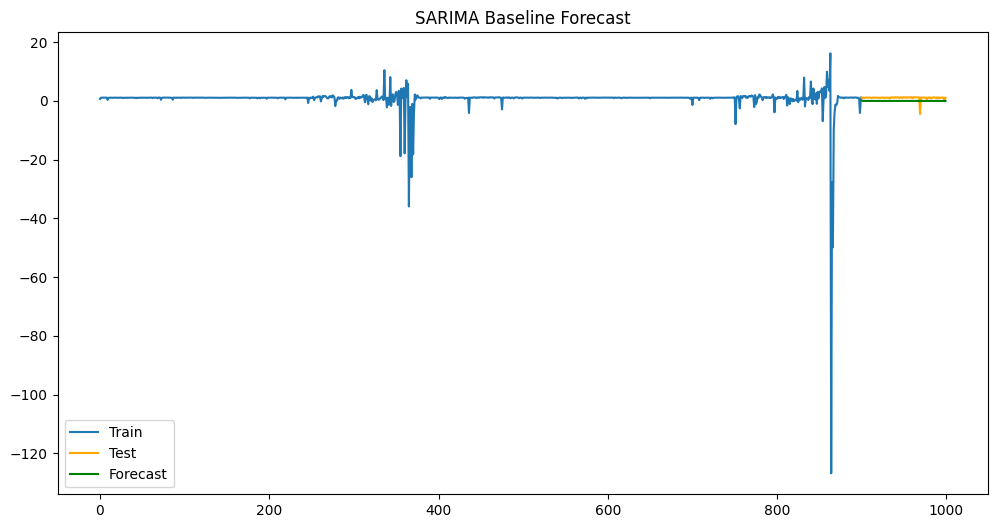

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# CONFIG
# ----------------------------
target = 'liquidity_ratio'
order = (1, 1, 1)               # (p,d,q) — tune later
seasonal_order = (0, 0, 0, 0)   # (P,D,Q,s) — set if seasonality found

# ----------------------------
# PREPARE SERIES
# ----------------------------
dfc = df.copy()

# If a date column exists, sort by it and set as index
date_cols = [c for c in dfc.columns if 'date' in c.lower()]
if date_cols:
    dfc[date_cols[0]] = pd.to_datetime(dfc[date_cols[0]])
    dfc = dfc.sort_values(date_cols[0])
    dfc = dfc.set_index(date_cols[0])
else:
    # Otherwise, just use integer index
    dfc = dfc.reset_index(drop=True)

# Extract target series
y = dfc[target].astype(float)

# ----------------------------
# TRAIN/TEST SPLIT
# ----------------------------
split_idx = int(len(y) * 0.9)
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# ----------------------------
# FIT SARIMA
# ----------------------------
model = SARIMAX(
    endog=y_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

# ----------------------------
# FORECAST
# ----------------------------
y_pred = model_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)

# Align indices
y_pred.index = y_test.index

# ----------------------------
# METRICS
# ----------------------------
y_true = y_test.values
y_forecast = y_pred.values

rmse = np.sqrt(mean_squared_error(y_true, y_forecast))
mae = mean_absolute_error(y_true, y_forecast)
r2 = r2_score(y_true, y_forecast)

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Test', color='orange')
plt.plot(y_pred, label='Forecast', color='green')
plt.legend()
plt.title("SARIMA Baseline Forecast")
plt.show()

In [124]:
print(len(y_test), len(y_pred))

100 1


Tuning SARIMAX orders...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=6564.984, Time=0.12 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=5972.937, Time=0.38 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.51 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=6222.487, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=5864.905, Time=0.56 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=0.99 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=0.64 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=6218.989, Time=0.25 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=5839.261, Time=0.79 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=5950.403, Time=0.36 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=1.09 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=0.79 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=5836.041, Time=0.60 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=5948.556, Time=0.27 sec
 ARIMA(3,1,0)(2,1,1)[7]          

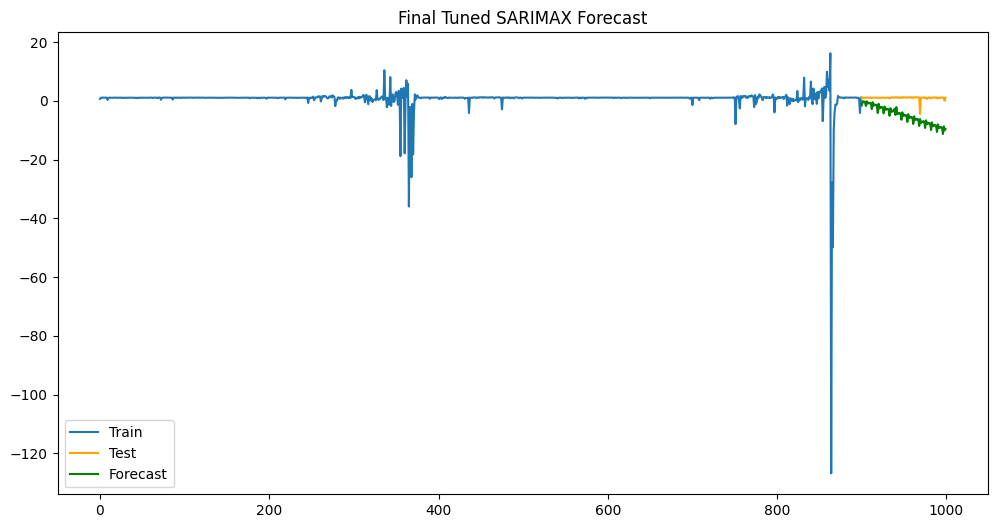

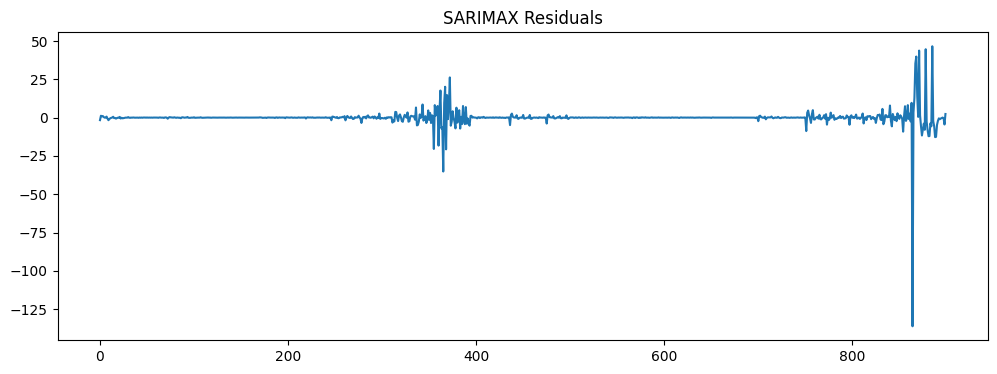

In [128]:
# Last Best shot. for SARIMAX


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# CONFIG
# ----------------------------
target = 'liquidity_ratio'
val_frac = 0.10

# ----------------------------
# PREPARE SERIES
# ----------------------------
dfc = df.copy()

# If date column exists, sort and set as index
date_cols = [c for c in dfc.columns if 'date' in c.lower()]
if date_cols:
    dfc[date_cols[0]] = pd.to_datetime(dfc[date_cols[0]])
    dfc = dfc.sort_values(date_cols[0])
    dfc = dfc.set_index(date_cols[0])
else:
    dfc = dfc.reset_index(drop=True)

y = dfc[target].astype(float)

# Stable exogenous features
candidate_exog = []
if 'volume_change_pct' in dfc.columns:
    candidate_exog.append('volume_change_pct')
if 'mkt_cap' in dfc.columns:
    candidate_exog.append('mkt_cap')

exog_features = [c for c in candidate_exog if c in dfc.columns]
use_exog = len(exog_features) > 0
if use_exog:
    # Smooth to reduce noise
    dfc[exog_features] = dfc[exog_features].rolling(3, min_periods=1).mean()
    X = dfc[exog_features].fillna(0.0)
else:
    X = None

# ----------------------------
# TRAIN/TEST SPLIT
# ----------------------------
split_idx = int(len(y) * (1 - val_frac))
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
if use_exog:
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
else:
    X_train = X_test = None

# ----------------------------
# AUTO-ARIMA with constraints
# ----------------------------
print("Tuning SARIMAX orders...")
auto_model = auto_arima(
    y_train,
    exogenous=X_train if use_exog else None,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    d=1, D=1,                # Force differencing
    seasonal=True, m=7,       # Weekly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("Best order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

# ----------------------------
# FIT FINAL SARIMAX
# ----------------------------
model = SARIMAX(
    endog=y_train,
    exog=X_train if use_exog else None,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

# ----------------------------
# FORECAST
# ----------------------------
y_pred = model_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test if use_exog else None
)
y_pred.index = y_test.index

# ----------------------------
# METRICS
# ----------------------------
y_true = y_test.values
y_forecast = y_pred.values

rmse = np.sqrt(mean_squared_error(y_true, y_forecast))
mae = mean_absolute_error(y_true, y_forecast)
r2 = r2_score(y_true, y_forecast)

print(f"\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Test', color='orange')
plt.plot(y_pred, label='Forecast', color='green')
plt.legend()
plt.title("Final Tuned SARIMAX Forecast")
plt.show()

# ----------------------------
# RESIDUAL CHECK
# ----------------------------
residuals = model_fit.resid
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("SARIMAX Residuals")
plt.show()

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# PREPARE DATA
# ----------------------------

df1 = pd.read_csv('..\datasets\coin_gecko_2022-03-16.csv')
df2 = pd.read_csv('..\datasets\coin_gecko_2022-03-17.csv')

df1.head()
df2.head()
df = pd.concat([df1, df2])
print(df.head())

dfc = df.copy()

df['liquidity_ratio'] = df['liquidity_ratio'].fillna(method='ffill')


df['date'] = pd.to_datetime(df['date'])

df.rename(columns={'date': 'ds', 'liquidity_ratio': 'y'}, inplace=True)

# Prophet needs columns: ds (datetime) and y (target)
date_cols = [c for c in dfc.columns if 'date' in c.lower()]
if date_cols:
    dfc[date_cols[0]] = pd.to_datetime(dfc[date_cols[0]])
    dfc = dfc.sort_values(date_cols[0])
    dfc.rename(columns={date_cols[0]: 'ds', 'liquidity_ratio': 'y'}, inplace=True)
else:
    # If no date column, create a synthetic daily index
    dfc['ds'] = pd.date_range(start='2000-01-01', periods=len(dfc), freq='D')
    dfc.rename(columns={'liquidity_ratio': 'y'}, inplace=True)

# ----------------------------
# OPTIONAL: ADD EXTERNAL REGRESSORS
# ----------------------------
exog_features = []
if 'volume_change_pct' in dfc.columns:
    exog_features.append('volume_change_pct')
if 'mkt_cap' in dfc.columns:
    exog_features.append('mkt_cap')

# Fill NAs for regressors
for col in exog_features:
    dfc[col] = dfc[col].fillna(0.0)

# ----------------------------
# TRAIN/TEST SPLIT
# ----------------------------
val_frac = 0.10
split_idx = int(len(dfc) * (1 - val_frac))
train_df = dfc.iloc[:split_idx]
test_df = dfc.iloc[split_idx:]

# ----------------------------
# BUILD PROPHET MODEL
# ----------------------------
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',  # or 'multiplicative' if effects scale with trend
    changepoint_prior_scale=0.5   # can tune for more/less trend flexibility
)

# Add regressors if available
for col in exog_features:
    m.add_regressor(col)

# Fit model
m.fit(train_df[['ds', 'y'] + exog_features])

# ----------------------------
# FORECAST
# ----------------------------
future = test_df[['ds'] + exog_features] if exog_features else test_df[['ds']]
forecast = m.predict(future)

# ----------------------------
# METRICS
# ----------------------------
y_true = test_df['y'].values
y_pred = forecast['yhat'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(train_df['ds'], train_df['y'], label='Train')
plt.plot(test_df['ds'], test_df['y'], label='Test', color='orange')
plt.plot(test_df['ds'], y_pred, label='Forecast', color='green')
plt.legend()
plt.title("Prophet Forecast")
plt.show()

# Prophet's own plot
m.plot(forecast)
plt.show()

# Components plot (trend + seasonality)
m.plot_components(forecast)
plt.show()

       coin symbol         price     1h    24h     7d    24h_volume  \
0   Bitcoin    BTC  40859.460000  0.022  0.030  0.055  3.539076e+10   
1  Ethereum    ETH   2744.410000  0.024  0.034  0.065  1.974870e+10   
2    Tether   USDT      1.000000 -0.001 -0.001  0.000  5.793497e+10   
3       BNB    BNB    383.430000  0.018  0.028  0.004  1.395854e+09   
4  USD Coin   USDC      0.999874 -0.001  0.000 -0.000  3.872274e+09   

        mkt_cap        date  
0  7.709915e+11  2022-03-16  
1  3.271044e+11  2022-03-16  
2  7.996516e+10  2022-03-16  
3  6.404382e+10  2022-03-16  
4  5.222214e+10  2022-03-16  


KeyError: 'liquidity_ratio'

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# CONFIG
# ----------------------------
target_col = 'liquidity_ratio'
val_frac = 0.10
stable_regressors = ['volume_change_pct', 'mkt_cap']  # optional

# ----------------------------
# PREP & CLEAN
# ----------------------------
dfc = df.copy()

# 1. Ensure target exists
if target_col not in dfc.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

# 2. Fill missing target values (forward fill, then backfill if needed)
dfc[target_col] = dfc[target_col].fillna(method='ffill').fillna(method='bfill')

# 3. Identify date column or create synthetic daily index
date_cols = [c for c in dfc.columns if 'date' in c.lower()]
if date_cols:
    dfc[date_cols[0]] = pd.to_datetime(dfc[date_cols[0]])
    dfc = dfc.sort_values(date_cols[0])
    dfc.rename(columns={date_cols[0]: 'ds', target_col: 'y'}, inplace=True)
else:
    dfc['ds'] = pd.date_range(start='2000-01-01', periods=len(dfc), freq='D')
    dfc.rename(columns={target_col: 'y'}, inplace=True)

# 4. Prepare regressors if available
exog_features = [c for c in stable_regressors if c in dfc.columns]
for col in exog_features:
    dfc[col] = dfc[col].fillna(0.0)

# ----------------------------
# TRAIN/TEST SPLIT
# ----------------------------
split_idx = int(len(dfc) * (1 - val_frac))
train_df = dfc.iloc[:split_idx]
test_df = dfc.iloc[split_idx:]

# ----------------------------
# BUILD PROPHET MODEL
# ----------------------------
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # try 'multiplicative' if effects scale with trend
    changepoint_prior_scale=5   # tune for more/less trend flexibility
)
m.add_seasonality(name='daily', period=1, fourier_order=5)
m.add_seasonality(name='weekly', period=7, fourier_order=3)
# Add regressors if available
for col in exog_features:
    m.add_regressor(col)

# Fit model
m.fit(train_df[['ds', 'y'] + exog_features])

# ----------------------------
# FORECAST
# ----------------------------
future = test_df[['ds'] + exog_features] if exog_features else test_df[['ds']]
forecast = m.predict(future)

# ----------------------------
# METRICS
# ----------------------------
y_true = test_df['y'].values
y_pred = forecast['yhat'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# ----------------------------
# PLOTS
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(train_df['ds'], train_df['y'], label='Train')
plt.plot(test_df['ds'], test_df['y'], label='Test', color='orange')
plt.plot(test_df['ds'], y_pred, label='Forecast', color='green')
plt.legend()
plt.title("Prophet Forecast")
plt.show()

# Prophet's own plots
m.plot(forecast)
plt.show()

m.plot_components(forecast)
plt.show()

ValueError: Target column 'liquidity_ratio' not found in dataframe.

# A Clean ML Pipeline using Ligh GBM.


In [38]:
df

,coin,symbol,price,pct_change_1h,pct_change_24h,pct_change_7d,volume_24h,mkt_cap,date,rolling_volatility,rolling_mean_price_7d,rolling_volatility_7d,liquidity_ratio,price_momentum,volume_change_pct,volume_zscore
0,Bitcoin,BTC,4.085946e+04,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16,0.000000,40859.460000,0.000000,0.045903,0.000000,0.000000,12.717313
1,Iron Bank EURO,IBEUR,1.080000e+00,0.000,-0.004,0.009,9.525810e+04,1.300442e+08,2022-03-16,0.000000,20430.270000,28891.237566,0.000733,-40858.380000,-0.999997,-0.104065
2,Prometeus,PROM,7.960000e+00,0.017,0.008,0.015,1.069360e+06,1.302007e+08,2022-03-16,0.000000,13622.833333,23587.610858,0.008213,6.880000,10.225922,-0.103712
3,MaidSafeCoin,MAID,2.949200e-01,0.023,0.010,0.045,3.041720e+03,1.327759e+08,2022-03-16,0.000000,10217.198730,20428.174470,0.000023,-7.665080,-0.997156,-0.104098
4,Bezoge Earth,BEZOGE,3.051000e-09,0.012,-0.005,-0.041,1.894020e+05,1.329136e+08,2022-03-16,0.000000,8173.758984,18271.862634,0.001425,-0.294920,61.268059,-0.104031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Ontology,ONT,5.099020e-01,0.004,0.021,-0.027,2.650433e+07,4.466601e+08,2022-03-17,54.760605,22.133529,54.760605,0.059339,-0.008258,0.094121,-0.094497
996,Siacoin,SC,8.924907e-03,0.006,0.002,-0.058,8.429351e+06,4.485693e+08,2022-03-17,54.788422,22.073855,54.788422,0.018792,-0.500977,-0.681963,-0.101046
997,Baby Doge Coin,BABYDOGE,2.830000e-09,0.004,-0.012,-0.071,9.830393e+06,4.499018e+08,2022-03-17,55.069962,21.388141,55.069962,0.021850,-0.008925,0.166210,-0.100538
998,Olympus,OHM,2.785000e+01,0.002,-0.005,-0.147,8.810942e+06,3.911910e+08,2022-03-17,54.445364,25.020998,54.445364,0.022523,27.850000,-0.103704,-0.100907


In [78]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# CONFIG
# ----------------------------
target_col = 'liquidity_ratio'
val_frac = 0.10
lag_list = [1, 2, 3, 7, 14]
roll_windows = [3, 7, 14]

# ----------------------------
# FEATURE ENGINEERING
# ----------------------------
dfc = df.copy()

# Ensure datetime index
date_cols = [c for c in dfc.columns if 'date' in c.lower()]
if date_cols:
    dfc[date_cols[0]] = pd.to_datetime(dfc[date_cols[0]])
    dfc = dfc.sort_values(date_cols[0])
else:
    dfc['date'] = pd.date_range(start='2000-01-01', periods=len(dfc), freq='D')

dfc = dfc.set_index(date_cols[0] if date_cols else 'date')

# Fill missing target
dfc[target_col] = dfc[target_col].fillna(method='ffill').fillna(method='bfill')

# Lag features
for lag in lag_list:
    dfc[f'lag_{lag}'] = dfc[target_col].shift(lag)

# Rolling stats
for w in roll_windows:
    dfc[f'roll_mean_{w}'] = dfc[target_col].shift(1).rolling(w).mean()
    dfc[f'roll_std_{w}'] = dfc[target_col].shift(1).rolling(w).std()

# Drift/shock features (example: z-score of change)
delta = dfc[target_col].diff()
dfc['shock_z'] = (delta - delta.rolling(30).mean()) / (delta.rolling(30).std() + 1e-8)

# Calendar features
dfc['dayofweek'] = dfc.index.dayofweek
dfc['month'] = dfc.index.month

# External drivers (if present)
exog_features = []
for col in ['volume_change_pct', 'mkt_cap']:
    if col in dfc.columns:
        dfc[col] = dfc[col].fillna(0.0)
        exog_features.append(col)

# ----------------------------
# DROP NA from lag creation
# ----------------------------
dfc = dfc.dropna()

# ----------------------------
# TRAIN/TEST SPLIT
# ----------------------------
split_idx = int(len(dfc) * (1 - val_frac))
train_df = dfc.iloc[:split_idx]
test_df = dfc.iloc[split_idx:]

feature_cols = [c for c in dfc.columns if c != target_col]
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

# ---------------------------
# Dropping non-numeric cols.
# ---------------------------
# drop_cols = ['coin', 'symbol']  # add any other non-numeric columns
# X_train = X_train.drop(columns=drop_cols, errors='ignore')
# X_test = X_test.drop(columns=drop_cols, errors='ignore')

from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['coin', 'symbol']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols].astype(str))
X_test[cat_cols] = encoder.transform(X_test[cat_cols].astype(str))

# ----------------------------
# LIGHTGBM MODEL
# ----------------------------
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'max_depth': 10,
    'min_data_in_leaf': 100,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'verbose': -1
}

model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_eval],
    num_boost_round=2000,
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]

)

# ----------------------------
# EVALUATE
# ----------------------------
y_pred = model.predict(X_test, num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.330483	valid_1's rmse: 0.089011
[200]	training's rmse: 0.30623	valid_1's rmse: 0.0751245
[300]	training's rmse: 0.285794	valid_1's rmse: 0.0675415
[400]	training's rmse: 0.272704	valid_1's rmse: 0.0635864
Early stopping, best iteration is:
[432]	training's rmse: 0.268903	valid_1's rmse: 0.0619987
RMSE: 0.0620, MAE: 0.0407, R²: 0.8215


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's rmse: 0.349014	valid_1's rmse: 0.104567
Fold 1: RMSE=0.1046, MAE=0.0838, R²=-0.1131
Training until validation scores don't improve for 50 rounds
[200]	training's rmse: 0.26534	valid_1's rmse: 0.45556
[400]	training's rmse: 0.244283	valid_1's rmse: 0.428333
[600]	training's rmse: 0.228525	valid_1's rmse: 0.407372
[800]	training's rmse: 0.216554	valid_1's rmse: 0.393636
[1000]	training's rmse: 0.206301	valid_1's rmse: 0.380981
[1200]	training's rmse: 0.198825	valid_1's rmse: 0.37335
[1400]	training's rmse: 0.19156	valid_1's rmse: 0.367621
[1600]	training's rmse: 0.184999	valid_1's rmse: 0.364807
[1800]	training's rmse: 0.179327	valid_1's rmse: 0.361537
Early stopping, best iteration is:
[1855]	training's rmse: 0.177643	valid_1's rmse: 0.360971
Fold 2: RMSE=0.3610, MAE=0.1229, R²=0.5389
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is

In [92]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================
# CONFIG
# ============================
target_col = 'liquidity_ratio'
n_splits = 5
min_train_frac = 0.5  # first training window size (fraction of series)
random_state = 42

# Use your tuned-ish params with a touch of stability
lgbm_params = dict(
    objective='regression',
    boosting_type='gbdt',
    learning_rate=0.03,
    n_estimators=5000,        # upper cap; early stopping will halt earlier
    max_depth=8,              # a bit shallower for stability
    num_leaves=31,
    min_data_in_leaf=200,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    subsample_freq=0,
    reg_alpha=0.0,
    reg_lambda=0.0,
    verbose=-1,
    random_state=random_state
)

# Feature choices (leakage-safe; all shifted)
lag_list = [1, 2, 3, 7, 14]
roll_windows = [3, 7, 14, 30]

# ============================
# PREP BASE DATAFRAME
# - Assumes df is already in memory
# ============================
dfc = df.copy()

# Ensure datetime index
date_cols = [c for c in dfc.columns if 'date' in c.lower() or c.lower() in ('ds', 'timestamp', 'time')]
if date_cols:
    dcol = date_cols[0]
    dfc[dcol] = pd.to_datetime(dfc[dcol])
    dfc = dfc.sort_values(dcol).set_index(dcol)
else:
    dfc['date'] = pd.date_range(start='2000-01-01', periods=len(dfc), freq='D')
    dfc = dfc.set_index('date')

# Target clean
dfc[target_col] = pd.to_numeric(dfc[target_col], errors='coerce').ffill().bfill()

# Drop obviously non-numeric ID columns now (if present)
for col in list(dfc.columns):
    if dfc[col].dtype == 'object':
        dfc = dfc.drop(columns=[col])

# ============================
# FEATURE ENGINEERING (leakage-safe)
# ============================
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Lags on level
    for lag in lag_list:
        out[f'lag_{lag}'] = out[target_col].shift(lag)

    # Rolling stats on level using only past info (shifted)
    for w in roll_windows:
        out[f'roll_mean_{w}'] = out[target_col].shift(1).rolling(w).mean()
        out[f'roll_std_{w}']  = out[target_col].shift(1).rolling(w).std()

    # Simple momentum features (pct change) shifted
    out['ret_1'] = out[target_col].pct_change().shift(1)
    for w in [3, 7, 14]:
        out[f'ret_{w}'] = out[target_col].pct_change(w).shift(1)

    # Replace infs and drop rows with NaNs introduced by rolling/shift
    out = out.replace([np.inf, -np.inf], np.nan).dropna()

    return out

df_feat = build_features(dfc)

# ============================
# WFV SPLITS (expanding window)
# ============================
total_len = len(df_feat)
start_train_size = int(total_len * min_train_frac)
fold_size = max(1, (total_len - start_train_size) // n_splits)

feature_cols = [c for c in df_feat.columns if c != target_col]

metrics = []

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for fold in range(n_splits):
    train_end = start_train_size + fold * fold_size
    test_end = total_len if fold == n_splits - 1 else train_end + fold_size

    train_df = df_feat.iloc[:train_end]
    test_df  = df_feat.iloc[train_end:test_end]
    if len(test_df) == 0:
        break

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    X_test  = test_df[feature_cols].copy()
    y_test  = test_df[target_col].copy()

    # Safety: clean NaN/inf per fold
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Model
    model = LGBMRegressor(**lgbm_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        eval_metric='rmse',
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=200)]
        
    )

    y_pred = model.predict(X_test, num_iteration=model.best_iteration_)
    rmse, mae, r2 = evaluate(y_test, y_pred)
    metrics.append((fold + 1, rmse, mae, r2))
    print(f"Fold {fold+1}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# ============================
# SUMMARY
# ============================
avg_rmse = float(np.mean([m[1] for m in metrics])) if metrics else np.nan
avg_mae  = float(np.mean([m[2] for m in metrics])) if metrics else np.nan
avg_r2   = float(np.mean([m[3] for m in metrics])) if metrics else np.nan

print("\n=== WFV Summary (Raw target) ===")
print(f"Avg RMSE: {avg_rmse:.4f}")
print(f"Avg MAE:  {avg_mae:.4f}")
print(f"Avg R²:   {avg_r2:.4f}")

# Optional: per-fold table
try:
    summary_df = pd.DataFrame(metrics, columns=['Fold', 'RMSE', 'MAE', 'R2'])
    print("\nPer-fold metrics:\n", summary_df.to_string(index=False))
except Exception:
    pass

KeyError: 'liquidity_ratio'